# DVG Analysis — Hamster Influenza Infection Study

Comprehensive analysis of defective viral genome (DVG) detection results from a golden hamster influenza infection experiment.

**Experimental design:** 3 × 2 × 2 factorial (Infection [H5N1 / H7N9 / PBS] × Sex × Timepoint [3 / 6 dpi]), n = 6 per group, 72 total samples. DVG calling performed on the 48 infected (non-PBS) samples using a ViReMa-based Nextflow pipeline.

**Long DVG definition:** deletion_length < 500 nt (small deletion → nearly full-length DVG RNA).

## Chapter 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import glob
import gzip
import json
import os
import re
from pathlib import Path
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Ensure working directory is project root
if not Path('data').exists() and Path('../data').exists():
    os.chdir('..')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# --- Visualization style ---
SURFACE = '#fcfcfb'
INK_1 = '#0b0b0b'
INK_2 = '#52514e'
INK_MUTED = '#898781'
GRID_CLR = '#e1e0d9'
AXIS_CLR = '#c3c2b7'

PAL = {
    'blue': '#2a78d6', 'orange': '#eb6834',
    'aqua': '#1baf7a', 'yellow': '#eda100',
    'magenta': '#e87ba4', 'green': '#008300',
    'violet': '#4a3aa7', 'red': '#e34948',
}
CAT_COLORS = list(PAL.values())
VIRUS_PAL = {'H5N1': PAL['blue'], 'H7N9': PAL['orange']}
SEX_PAL = {'female': PAL['orange'], 'male': PAL['blue']}
TP_PAL = {'3dpi': PAL['blue'], '6dpi': PAL['orange']}

SEG_PAL = {
    s: CAT_COLORS[i] for i, s in enumerate([
        'PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'M', 'NS'
    ])
}

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': AXIS_CLR,
    'axes.linewidth': 0.8,
    'axes.labelcolor': INK_2,
    'axes.titlecolor': INK_1,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRID_CLR,
    'grid.linewidth': 0.5,
    'grid.alpha': 1.0,
    'text.color': INK_1,
    'font.family': ['system-ui', 'sans-serif'],
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
    'figure.figsize': (10, 4.5),
    'legend.frameon': False,
    'legend.fontsize': 9,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
})

FIGURES_DIR = Path('analysis/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- Constants ---
BASE_DIR = Path('data')
DVG_DIR = BASE_DIR / 'DVG' / 'run1'
REFS_DIR = BASE_DIR / 'refs'

SEGMENT_LENGTHS = {
    'PB2': 2280, 'PB1': 2274, 'PA': 2151, 'HA': 1704,
    'NP': 1497, 'NA': 1410, 'M': 982, 'NS': 838,
}
SEGMENT_ORDER = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'M', 'NS']
LONG_DVG_THRESHOLD = 500


def parse_sample_dir(dirname):
    """Extract metadata from sample directory name."""
    m = re.search(
        r'_F(\d+)_(\d+)_(male|female)_(H5N1|H7N9)_(\d+)dpi$',
        dirname,
    )
    if m:
        return {
            'cage': f'F{m.group(1)}',
            'animal': m.group(2),
            'sex': m.group(3),
            'virus': m.group(4),
            'timepoint': f'{m.group(5)}dpi',
        }
    return None


# Load segment maps (accession → segment name)
seg_maps = {}
for virus in ['H5N1', 'H7N9']:
    sm = pd.read_csv(
        REFS_DIR / f'.segment_map_{virus}.tsv',
        sep='\t', header=None, names=['accession', 'segment'],
    )
    seg_maps[virus] = dict(zip(sm['accession'], sm['segment']))

print('Segment maps loaded:')
for v, mapping in seg_maps.items():
    print(f'  {v}: {list(mapping.values())}')

Segment maps loaded:
  H5N1: ['PB2', 'PB1', 'PA', 'HA', 'NP', nan, 'M', 'NS']
  H7N9: ['PB2', 'PB1', 'PA', 'HA', 'NP', nan, 'M', 'NS']


### 1.1 Load final DVG CSVs

In [3]:
dvg_records = []
sample_status = []

for sample_dir in sorted(DVG_DIR.iterdir()):
    if not sample_dir.is_dir() or sample_dir.name.startswith('.'):
        continue

    dirname = sample_dir.name
    meta = parse_sample_dir(dirname)
    if meta is None:
        continue

    final_files = list((sample_dir / 'final').glob('*.csv.gz'))
    pregate_files = list((sample_dir / 'qc').glob('*.pregate.tsv'))

    if pregate_files and not final_files:
        pg = pd.read_csv(pregate_files[0], sep='\t')
        sample_status.append({
            'sample_name': dirname, **meta,
            'status': pg['decision'].iloc[0], 'n_dvgs': 0,
        })
        continue

    if not final_files:
        sample_status.append({
            'sample_name': dirname, **meta,
            'status': 'NO_OUTPUT', 'n_dvgs': 0,
        })
        continue

    df = pd.read_csv(
        final_files[0], keep_default_na=False, na_values=['']
    )
    df['sample_name'] = dirname
    for k, v in meta.items():
        df[k] = v

    dvg_records.append(df)
    sample_status.append({
        'sample_name': dirname, **meta,
        'status': 'OK', 'n_dvgs': len(df),
    })

df_dvg = pd.concat(dvg_records, ignore_index=True)
df_status = pd.DataFrame(sample_status)

print(f'Loaded {len(df_dvg):,} DVG junctions from '
      f'{len(dvg_records)} samples')
print()
display(Markdown('**Sample status:**'))
display(df_status['status'].value_counts().to_frame('count'))
print()
excluded = df_status[df_status['status'] != 'OK']
if not excluded.empty:
    display(Markdown('**Excluded samples:**'))
    display(excluded[['sample_name', 'virus', 'sex', 'timepoint', 'status']])

Loaded 36,916 DVG junctions from 45 samples



**Sample status:**

,count
status,
OK,45
SKIP_LOW_COVERAGE,3


**Excluded samples:**

,sample_name,virus,sex,timepoint,status
28,tl50L2_20260721_Amplicon_F9_2_male_H7N9_6dpi,H7N9,male,6dpi,SKIP_LOW_COVERAGE
31,tl53L1_20260721_Amplicon_F9_5_male_H7N9_6dpi,H7N9,male,6dpi,SKIP_LOW_COVERAGE
36,tl64L1_20260721_Amplicon_F20_4_female_H5N1_6dpi,H5N1,female,6dpi,SKIP_LOW_COVERAGE


### 1.2 Load .par files (strand support)

In [4]:
par_records = []

for sample_dir in sorted(DVG_DIR.iterdir()):
    if not sample_dir.is_dir() or sample_dir.name.startswith('.'):
        continue

    dirname = sample_dir.name
    meta = parse_sample_dir(dirname)
    if meta is None:
        continue

    virema_dir = sample_dir / 'virema'
    if not virema_dir.exists():
        continue

    par_files = list(virema_dir.glob(
        '*_Virus_Recombination_Results.par'
    ))
    if not par_files:
        continue

    df = pd.read_csv(par_files[0], sep='\t')
    if df.empty:
        continue

    acc_to_seg = seg_maps[meta['virus']]
    df['Segment'] = df['Segment'].map(acc_to_seg)
    df = df.rename(columns={'Stop': 'End'})
    df['sample_name'] = dirname
    for k, v in meta.items():
        df[k] = v

    par_records.append(df)

df_par = pd.concat(par_records, ignore_index=True)
print(f'Loaded {len(df_par):,} junction records from '
      f'{len(par_records)} .par files')

Loaded 36,916 junction records from 45 .par files


### 1.3 Load QC data

In [5]:
qc_records = []

for sample_dir in sorted(DVG_DIR.iterdir()):
    if not sample_dir.is_dir() or sample_dir.name.startswith('.'):
        continue

    dirname = sample_dir.name
    meta = parse_sample_dir(dirname)
    if meta is None:
        continue

    qc_dir = sample_dir / 'qc'
    record = {'sample_name': dirname, **meta}

    # fastp
    for fp in qc_dir.glob('*.fastp.json'):
        with open(fp) as f:
            fastp = json.load(f)
        s = fastp['summary']
        record['raw_reads'] = s['before_filtering']['total_reads']
        record['filtered_reads'] = s['after_filtering']['total_reads']
        record['q30_before'] = s['before_filtering']['q30_rate']
        record['q30_after'] = s['after_filtering']['q30_rate']
        break

    # flagstat
    for fs in qc_dir.glob('*.flagstat.txt'):
        with open(fs) as f:
            text = f.read()
        m_total = re.search(r'(\d+) \+ \d+ in total', text)
        m_mapped = re.search(
            r'(\d+) \+ \d+ mapped \(([0-9.]+)%', text
        )
        if m_total:
            record['total_reads_aligned'] = int(m_total.group(1))
        if m_mapped:
            record['mapped_reads'] = int(m_mapped.group(1))
            record['mapping_rate'] = float(m_mapped.group(2)) / 100
        break

    # coverage
    for cv in qc_dir.glob('*.coverage.tsv'):
        cov = pd.read_csv(cv, sep='\t')
        record['segments_passing'] = int(
            (cov['pass'] == 'YES').sum()
        )
        record['mean_coverage'] = cov['mean_coverage'].mean()
        record['min_coverage_seg'] = cov.loc[
            cov['mean_coverage'].idxmin(), 'segment'
        ]
        record['min_coverage'] = cov['mean_coverage'].min()
        break

    qc_records.append(record)

df_qc = pd.DataFrame(qc_records)
print(f'Loaded QC data for {len(df_qc)} samples')

Loaded QC data for 48 samples


### 1.4 Compute derived columns & sample-level aggregation

In [6]:
# --- Derived columns on df_dvg ---
df_dvg['deletion_length'] = df_dvg['End'] - df_dvg['Start']
df_dvg['segment_length'] = df_dvg['Segment'].map(SEGMENT_LENGTHS)
df_dvg['is_long_dvg'] = df_dvg['deletion_length'] < LONG_DVG_THRESHOLD
df_dvg['retained_length'] = (
    df_dvg['segment_length'] - df_dvg['deletion_length']
)
df_dvg['deletion_fraction'] = (
    df_dvg['deletion_length'] / df_dvg['segment_length']
)
df_dvg['sequence_length'] = df_dvg['Sequence'].str.len()
df_dvg['start_frac'] = df_dvg['Start'] / df_dvg['segment_length']
df_dvg['end_frac'] = df_dvg['End'] / df_dvg['segment_length']

# --- Derived columns on df_par ---
df_par['deletion_length'] = df_par['End'] - df_par['Start']
df_par['is_long_dvg'] = df_par['deletion_length'] < LONG_DVG_THRESHOLD
df_par['segment_length'] = df_par['Segment'].map(SEGMENT_LENGTHS)
df_par['strand_ratio'] = np.where(
    df_par['Total_support'] > 0,
    df_par['Forward_support'] / df_par['Total_support'],
    np.nan,
)

# --- Sample-level aggregation ---
agg_all = df_dvg.groupby('sample_name').agg(
    n_dvgs=('Segment', 'size'),
    total_support=('NGS_read_count', 'sum'),
    n_segments_with_dvg=('Segment', 'nunique'),
    mean_deletion_length=('deletion_length', 'mean'),
    median_deletion_length=('deletion_length', 'median'),
).reset_index()

agg_long = (
    df_dvg[df_dvg['is_long_dvg']]
    .groupby('sample_name')
    .agg(
        n_long_dvgs=('Segment', 'size'),
        long_dvg_support=('NGS_read_count', 'sum'),
    )
    .reset_index()
)

df_sample = agg_all.merge(agg_long, on='sample_name', how='left')
df_sample[['n_long_dvgs', 'long_dvg_support']] = (
    df_sample[['n_long_dvgs', 'long_dvg_support']].fillna(0)
)

meta_cols = ['sample_name', 'virus', 'sex', 'timepoint']
df_meta = df_dvg[meta_cols].drop_duplicates()
df_sample = df_sample.merge(df_meta, on='sample_name')

df_sample['long_dvg_fraction'] = (
    df_sample['n_long_dvgs'] / df_sample['n_dvgs']
)
df_sample['long_dvg_support_fraction'] = (
    df_sample['long_dvg_support'] / df_sample['total_support']
)

print(f'Sample-level DataFrame: {len(df_sample)} samples, '
      f'{len(df_sample.columns)} columns')
display(df_sample.head())

Sample-level DataFrame: 45 samples, 13 columns


,sample_name,n_dvgs,total_support,n_segments_with_dvg,mean_deletion_length,median_deletion_length,n_long_dvgs,long_dvg_support,virus,sex,timepoint,long_dvg_fraction,long_dvg_support_fraction
0,tl10L1_20260721_Amplicon_F11_4_male_H5N1_3dpi,1108,37196,8,1308.419,1482.000,182,503,H5N1,male,3dpi,0.164,0.014
1,tl11L1_20260721_Amplicon_F11_5_male_H5N1_3dpi,2459,362285,8,1220.724,1305.000,495,6555,H5N1,male,3dpi,0.201,0.018
2,tl12L1_20260721_Amplicon_F11_6_male_H5N1_3dpi,1219,240815,8,1170.939,1273.000,325,11237,H5N1,male,3dpi,0.267,0.047
3,tl13L2_20260721_Amplicon_F12_1_male_H7N9_3dpi,2820,738608,8,1402.700,1708.500,450,17020,H7N9,male,3dpi,0.160,0.023
4,tl14L2_20260721_Amplicon_F12_2_male_H7N9_3dpi,1566,540814,8,1361.169,1666.500,267,8833,H7N9,male,3dpi,0.170,0.016


### 1.5 Data loading summary

In [7]:
display(Markdown('### Data loading summary'))
print(f'Total DVG junctions loaded:     {len(df_dvg):>8,}')
print(f'Samples with DVG data:          {df_sample["sample_name"].nunique():>8}')
print(f'Samples excluded (pre-gate):    '
      f'{(df_status["status"] == "SKIP_LOW_COVERAGE").sum():>8}')
print(f'Unique segments represented:    '
      f'{df_dvg["Segment"].nunique():>8}')
print(f'Long DVGs (del < {LONG_DVG_THRESHOLD} nt):     '
      f'{df_dvg["is_long_dvg"].sum():>8} '
      f'({df_dvg["is_long_dvg"].mean():.1%})')
print()
print('Samples per group:')
display(
    df_sample.groupby(['virus', 'sex', 'timepoint'])
    .size()
    .unstack('timepoint')
    .rename_axis(columns=None)
)

### Data loading summary

Total DVG junctions loaded:       36,916
Samples with DVG data:                45
Samples excluded (pre-gate):           3
Unique segments represented:           8
Long DVGs (del < 500 nt):         6963 (18.9%)

Samples per group:


3dpi  6dpi
virus sex               
H5N1  female     6     5
      male       6     6
H7N9  female     6     6
      male       6     4

## Chapter 2 — QC Overview

In [8]:
# Restrict QC to samples that passed pre-gating
ok_samples = df_status[df_status['status'] == 'OK']['sample_name']
df_qc_ok = df_qc[df_qc['sample_name'].isin(ok_samples)].copy()

display(Markdown('### Per-sample QC summary'))
qc_display = df_qc_ok[[
    'sample_name', 'virus', 'sex', 'timepoint',
    'raw_reads', 'filtered_reads', 'mapping_rate',
    'segments_passing', 'mean_coverage',
]].copy()
qc_display['filtering_rate'] = (
    1 - qc_display['filtered_reads'] / qc_display['raw_reads']
)
display(qc_display.sort_values('sample_name').reset_index(drop=True))

### Per-sample QC summary

,sample_name,virus,sex,timepoint,raw_reads,filtered_reads,mapping_rate,segments_passing,mean_coverage,filtering_rate
0,tl10L1_20260721_Amplicon_F11_4_male_H5N1_3dpi,H5N1,male,3dpi,1167324.000,932182.000,0.147,4.000,1927.050,0.201
1,tl11L1_20260721_Amplicon_F11_5_male_H5N1_3dpi,H5N1,male,3dpi,11073402.000,9381586.000,0.125,8.000,15289.238,0.153
2,tl12L1_20260721_Amplicon_F11_6_male_H5N1_3dpi,H5N1,male,3dpi,9400552.000,7473866.000,0.135,8.000,13237.000,0.205
3,tl13L2_20260721_Amplicon_F12_1_male_H7N9_3dpi,H7N9,male,3dpi,9195956.000,7966942.000,0.672,8.000,57985.775,0.134
4,tl14L2_20260721_Amplicon_F12_2_male_H7N9_3dpi,H7N9,male,3dpi,9195598.000,7460778.000,0.594,8.000,49613.125,0.189
5,tl15L2_20260721_Amplicon_F12_3_male_H7N9_3dpi,H7N9,male,3dpi,14786836.000,9068566.000,0.257,4.000,26682.275,0.387
6,tl16L1_20260721_Amplicon_F12_4_male_H7N9_3dpi,H7N9,male,3dpi,11109210.000,9094344.000,0.588,8.000,60024.675,0.181
7,tl17L1_20260721_Amplicon_F12_5_male_H7N9_3dpi,H7N9,male,3dpi,7850378.000,6574222.000,0.628,8.000,44733.488,0.163
8,tl18L1_20260721_Amplicon_F12_6_male_H7N9_3dpi,H7N9,male,3dpi,4270980.000,3493408.000,0.637,7.000,24435.713,0.182
9,tl25L2_20260721_Amplicon_F17_1_female_H5N1_3dpi,H5N1,female,3dpi,6598636.000,5583028.000,0.153,8.000,11673.362,0.154


In [9]:
display(Markdown('### Group-level QC summary'))
for group_col in ['virus', 'sex', 'timepoint']:
    print(f'\n--- By {group_col} ---')
    summary = df_qc_ok.groupby(group_col).agg(
        n=('sample_name', 'size'),
        raw_reads_mean=('raw_reads', 'mean'),
        raw_reads_std=('raw_reads', 'std'),
        filtered_reads_mean=('filtered_reads', 'mean'),
        mapping_rate_mean=('mapping_rate', 'mean'),
        mapping_rate_std=('mapping_rate', 'std'),
        mean_coverage_mean=('mean_coverage', 'mean'),
        segments_passing_mean=('segments_passing', 'mean'),
    )
    display(summary)

# Identify QC outliers (mapping rate < 1% or mean coverage < 100)
print('\n--- Potential QC outliers ---')
outliers = df_qc_ok[
    (df_qc_ok['mapping_rate'] < 0.01)
    | (df_qc_ok['mean_coverage'] < 100)
]
if outliers.empty:
    print('No outliers detected.')
else:
    display(outliers[[
        'sample_name', 'virus', 'mapping_rate',
        'mean_coverage', 'segments_passing',
    ]])

### Group-level QC summary


--- By virus ---


,n,raw_reads_mean,raw_reads_std,filtered_reads_mean,mapping_rate_mean,mapping_rate_std,mean_coverage_mean,segments_passing_mean
virus,,,,,,,,
H5N1,23,9715402.174,4467390.049,6908428.696,0.093,0.055,8467.502,6.261
H7N9,22,8672949.182,4789618.771,5928970.364,0.275,0.220,21056.001,4.864



--- By sex ---


,n,raw_reads_mean,raw_reads_std,filtered_reads_mean,mapping_rate_mean,mapping_rate_std,mean_coverage_mean,segments_passing_mean
sex,,,,,,,,
female,23,8525808.000,5481759.255,5661145.043,0.143,0.112,11100.442,5.000
male,22,9916615.818,3451650.760,7232948.727,0.223,0.230,18303.382,6.182



--- By timepoint ---


,n,raw_reads_mean,raw_reads_std,filtered_reads_mean,mapping_rate_mean,mapping_rate_std,mean_coverage_mean,segments_passing_mean
timepoint,,,,,,,,
3dpi,24,9207900.500,3511062.737,7117128.083,0.273,0.205,22642.199,6.583
6dpi,21,9203310.476,5698689.810,5643815.905,0.078,0.058,5455.799,4.429



--- Potential QC outliers ---
No outliers detected.


### 2.1 QC visualizations

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


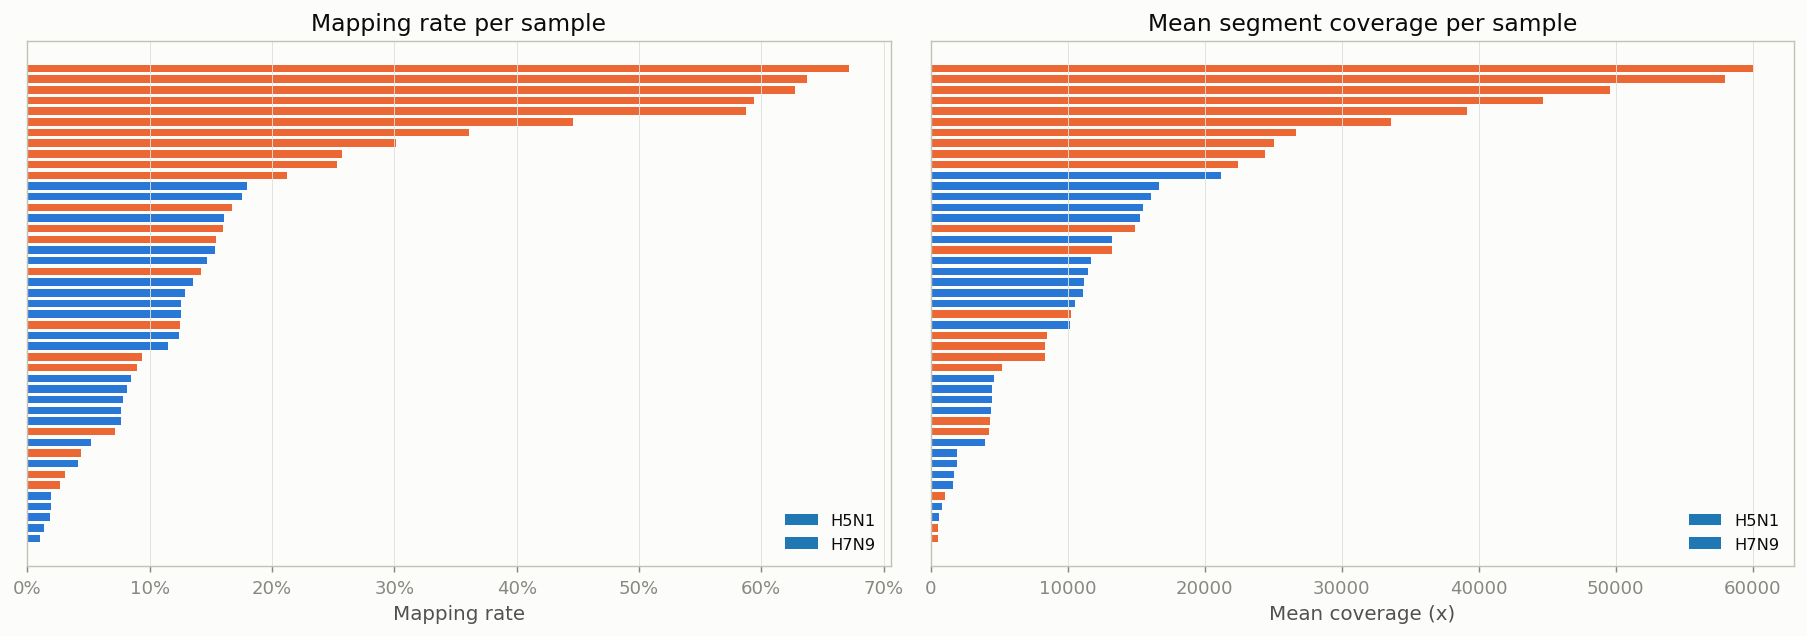

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapping rate per sample, colored by virus
ax = axes[0]
order = df_qc_ok.sort_values('mapping_rate')['sample_name']
colors = df_qc_ok.set_index('sample_name')['virus'].map(VIRUS_PAL)
ax.barh(
    range(len(order)), df_qc_ok.set_index('sample_name').loc[order, 'mapping_rate'],
    color=[colors[s] for s in order], height=0.7,
)
ax.set_yticks([])
ax.set_xlabel('Mapping rate')
ax.set_title('Mapping rate per sample')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='x', linewidth=0.5)
for v, c in VIRUS_PAL.items():
    ax.barh([], [], color=c, label=v)
ax.legend(loc='lower right')

# Mean coverage per sample
ax = axes[1]
order2 = df_qc_ok.sort_values('mean_coverage')['sample_name']
colors2 = df_qc_ok.set_index('sample_name')['virus'].map(VIRUS_PAL)
ax.barh(
    range(len(order2)),
    df_qc_ok.set_index('sample_name').loc[order2, 'mean_coverage'],
    color=[colors2[s] for s in order2], height=0.7,
)
ax.set_yticks([])
ax.set_xlabel('Mean coverage (x)')
ax.set_title('Mean segment coverage per sample')
ax.grid(axis='x', linewidth=0.5)
for v, c in VIRUS_PAL.items():
    ax.barh([], [], color=c, label=v)
ax.legend(loc='lower right')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch2_qc_overview.png')
plt.show()

## Chapter 3 — General DVG Landscape

### 3.1 Sample-level DVG counts and read support

In [11]:
display(Markdown('**DVG species count per sample:**'))
print(df_sample['n_dvgs'].describe().to_string())

print()
display(Markdown('**Total DVG read support per sample:**'))
print(df_sample['total_support'].describe().to_string())

print()
display(Markdown('**Number of segments with DVGs per sample:**'))
print(df_sample['n_segments_with_dvg'].value_counts()
      .sort_index().to_string())

**DVG species count per sample:**

count     45.000
mean     820.356
std      792.004
min       90.000
25%      191.000
50%      431.000
75%     1108.000
max     2820.000



**Total DVG read support per sample:**

count       45.000
mean    221112.933
std     211344.013
min      10862.000
25%      48312.000
50%     132486.000
75%     362285.000
max     778957.000



**Number of segments with DVGs per sample:**

n_segments_with_dvg
7     2
8    43


### 3.2 DVG-level descriptive statistics

In [12]:
display(Markdown('**Deletion length (nt):**'))
dl = df_dvg['deletion_length']
print(f'  Mean:   {dl.mean():.1f}')
print(f'  Median: {dl.median():.1f}')
print(f'  IQR:    {dl.quantile(0.25):.0f} – {dl.quantile(0.75):.0f}')
print(f'  Range:  {dl.min():.0f} – {dl.max():.0f}')

print()
display(Markdown('**Deletion fraction (of segment length):**'))
df_frac = df_dvg['deletion_fraction']
print(f'  Mean:   {df_frac.mean():.3f}')
print(f'  Median: {df_frac.median():.3f}')

print()
display(Markdown('**NGS read count per DVG junction:**'))
rc = df_dvg['NGS_read_count']
print(f'  Mean:   {rc.mean():.1f}')
print(f'  Median: {rc.median():.1f}')
print(f'  Max:    {rc.max():,}')
print(f'  DVGs with count ≤ 5:  '
      f'{(rc <= 5).sum()} ({(rc <= 5).mean():.1%})')
print(f'  DVGs with count > 100: '
      f'{(rc > 100).sum()} ({(rc > 100).mean():.1%})')

**Deletion length (nt):**

  Mean:   1307.8
  Median: 1561.0
  IQR:    738 – 1892
  Range:  21 – 2281



**Deletion fraction (of segment length):**

  Mean:   0.679
  Median: 0.802



**NGS read count per DVG junction:**

  Mean:   269.5
  Median: 4.0
  Max:    461,289
  DVGs with count ≤ 5:  20737 (56.2%)
  DVGs with count > 100: 3663 (9.9%)


### 3.3 Top 10 most-supported DVG junctions

In [13]:
top10 = (
    df_dvg.nlargest(10, 'NGS_read_count')
    [['sample_name', 'Segment', 'Start', 'End',
      'deletion_length', 'NGS_read_count', 'virus', 'timepoint']]
    .reset_index(drop=True)
)
display(top10)

,sample_name,Segment,Start,End,deletion_length,NGS_read_count,virus,timepoint
0,tl33L1_20260721_Amplicon_F18_3_female_H7N9_3dpi,NA,92,1246,1154,461289,H7N9,3dpi
1,tl13L2_20260721_Amplicon_F12_1_male_H7N9_3dpi,NA,92,1246,1154,327262,H7N9,3dpi
2,tl16L1_20260721_Amplicon_F12_4_male_H7N9_3dpi,NA,92,1246,1154,280108,H7N9,3dpi
3,tl17L1_20260721_Amplicon_F12_5_male_H7N9_3dpi,NA,92,1246,1154,279685,H7N9,3dpi
4,tl35L1_20260721_Amplicon_F18_5_female_H7N9_3dpi,NA,92,1246,1154,254488,H7N9,3dpi
5,tl14L2_20260721_Amplicon_F12_2_male_H7N9_3dpi,NA,92,1246,1154,251672,H7N9,3dpi
6,tl26L2_20260721_Amplicon_F17_2_female_H5N1_3dpi,NA,52,1326,1274,231226,H5N1,3dpi
7,tl34L1_20260721_Amplicon_F18_4_female_H7N9_3dpi,NA,92,1246,1154,206883,H7N9,3dpi
8,tl29L2_20260721_Amplicon_F17_5_female_H5N1_3dpi,NA,52,1326,1274,203782,H5N1,3dpi
9,tl15L2_20260721_Amplicon_F12_3_male_H7N9_3dpi,NA,92,1246,1154,168342,H7N9,3dpi


### 3.4 DVG landscape visualizations

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


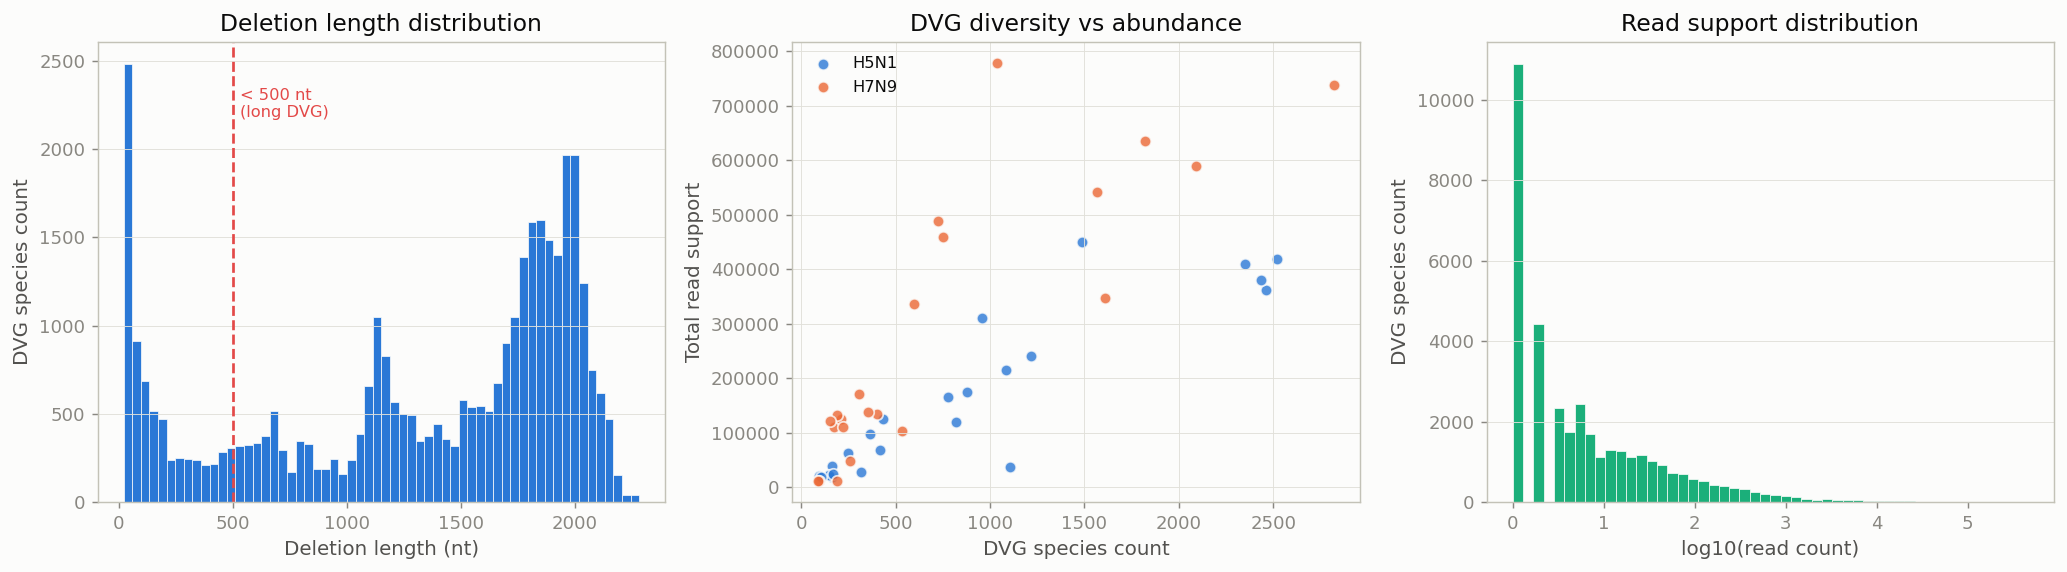

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Deletion length distribution
ax = axes[0]
ax.hist(
    df_dvg['deletion_length'], bins=60, color=PAL['blue'],
    edgecolor=SURFACE, linewidth=0.4,
)
ax.axvline(LONG_DVG_THRESHOLD, color=PAL['red'], linewidth=1.5, ls='--')
ax.text(
    LONG_DVG_THRESHOLD + 30, ax.get_ylim()[1] * 0.9,
    f'< {LONG_DVG_THRESHOLD} nt\n(long DVG)',
    color=PAL['red'], fontsize=9, va='top',
)
ax.set_xlabel('Deletion length (nt)')
ax.set_ylabel('DVG species count')
ax.set_title('Deletion length distribution')
ax.grid(axis='y', linewidth=0.5)

# DVG count per sample by virus
ax = axes[1]
for v in ['H5N1', 'H7N9']:
    sub = df_sample[df_sample['virus'] == v]
    ax.scatter(
        sub['n_dvgs'], sub['total_support'],
        color=VIRUS_PAL[v], label=v, s=40, alpha=0.8,
        edgecolors=SURFACE, linewidths=1,
    )
ax.set_xlabel('DVG species count')
ax.set_ylabel('Total read support')
ax.set_title('DVG diversity vs abundance')
ax.legend()
ax.grid(linewidth=0.5)

# Read count distribution (log)
ax = axes[2]
ax.hist(
    np.log10(df_dvg['NGS_read_count'].clip(lower=1)),
    bins=50, color=PAL['aqua'],
    edgecolor=SURFACE, linewidth=0.4,
)
ax.set_xlabel('log10(read count)')
ax.set_ylabel('DVG species count')
ax.set_title('Read support distribution')
ax.grid(axis='y', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch3_dvg_landscape.png')
plt.show()

### 3.5 Unique DVG species

Sections 3.1–3.4 count every junction–sample combination (36,916 rows). The same junction appearing in 8 samples is counted 8 times. Below, we deduplicate by Segment + Start + End (within each virus) to characterise the *distinct* DVG species.

In [15]:
# Deduplicate: one row per unique junction per virus
df_unique = (
    df_dvg
    .groupby(['virus', 'Segment', 'Start', 'End'])
    .agg(
        n_samples=('sample_name', 'nunique'),
        total_support=('NGS_read_count', 'sum'),
        mean_support=('NGS_read_count', 'mean'),
        deletion_length=('deletion_length', 'first'),
        segment_length=('segment_length', 'first'),
        is_long_dvg=('is_long_dvg', 'first'),
        start_frac=('start_frac', 'first'),
        end_frac=('end_frac', 'first'),
    )
    .reset_index()
)
df_unique['deletion_fraction'] = (
    df_unique['deletion_length'] / df_unique['segment_length']
)

n_uniq = len(df_unique)
n_uniq_long = df_unique['is_long_dvg'].sum()

print(f'Unique DVG species (per virus): {n_uniq:,}')
for v in ['H5N1', 'H7N9']:
    sub = df_unique[df_unique['virus'] == v]
    print(f'  {v}: {len(sub):,}')
print(f'Long DVG species: {n_uniq_long:,} '
      f'({n_uniq_long / n_uniq:.1%})')

print()
display(Markdown('**Deletion length — unique species:**'))
dl_u = df_unique['deletion_length']
print(f'  Mean:   {dl_u.mean():.1f}')
print(f'  Median: {dl_u.median():.1f}')
print(f'  IQR:    {dl_u.quantile(0.25):.0f} – {dl_u.quantile(0.75):.0f}')

print()
display(Markdown('**Read support — unique species:**'))
rc_u = df_unique['total_support']
print(f'  Mean total support:  {rc_u.mean():.1f}')
print(f'  Median:              {rc_u.median():.1f}')
print(f'  Species seen in 1 sample only: '
      f'{(df_unique["n_samples"] == 1).sum()} '
      f'({(df_unique["n_samples"] == 1).mean():.1%})')
print(f'  Species in ≥5 samples:         '
      f'{(df_unique["n_samples"] >= 5).sum()}')

Unique DVG species (per virus): 18,898
  H5N1: 11,944
  H7N9: 6,954
Long DVG species: 4,313 (22.8%)



**Deletion length — unique species:**

  Mean:   1198.5
  Median: 1295.5
  IQR:    575 – 1859



**Read support — unique species:**

  Mean total support:  526.5
  Median:              4.0
  Species seen in 1 sample only: 14048 (74.3%)
  Species in ≥5 samples:         1499


In [16]:
# Top 10 most-supported unique junctions (pooled across samples)
display(Markdown(
    '**Top 10 unique DVG species by total read support:**'
))
display(
    df_unique.nlargest(10, 'total_support')
    [['virus', 'Segment', 'Start', 'End',
      'deletion_length', 'is_long_dvg',
      'n_samples', 'total_support', 'mean_support']]
    .reset_index(drop=True)
)

**Top 10 unique DVG species by total read support:**

,virus,Segment,Start,End,deletion_length,is_long_dvg,n_samples,total_support,mean_support
0,H7N9,NA,92,1246,1154,False,22,3066081,139367.318
1,H5N1,NA,52,1326,1274,False,23,1396359,60711.261
2,H5N1,PB1,178,2033,1855,False,23,434666,18898.522
3,H7N9,NA,86,1240,1154,False,22,404262,18375.545
4,H7N9,NA,110,1241,1131,False,22,318255,14466.136
5,H5N1,HA,41,1438,1397,False,23,316385,13755.870
6,H5N1,PA,208,1901,1693,False,23,309729,13466.478
7,H7N9,NA,111,1259,1148,False,22,236888,10767.636
8,H7N9,NA,68,1166,1098,False,22,155310,7059.545
9,H7N9,PB1,60,2114,2054,False,20,154045,7702.250


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


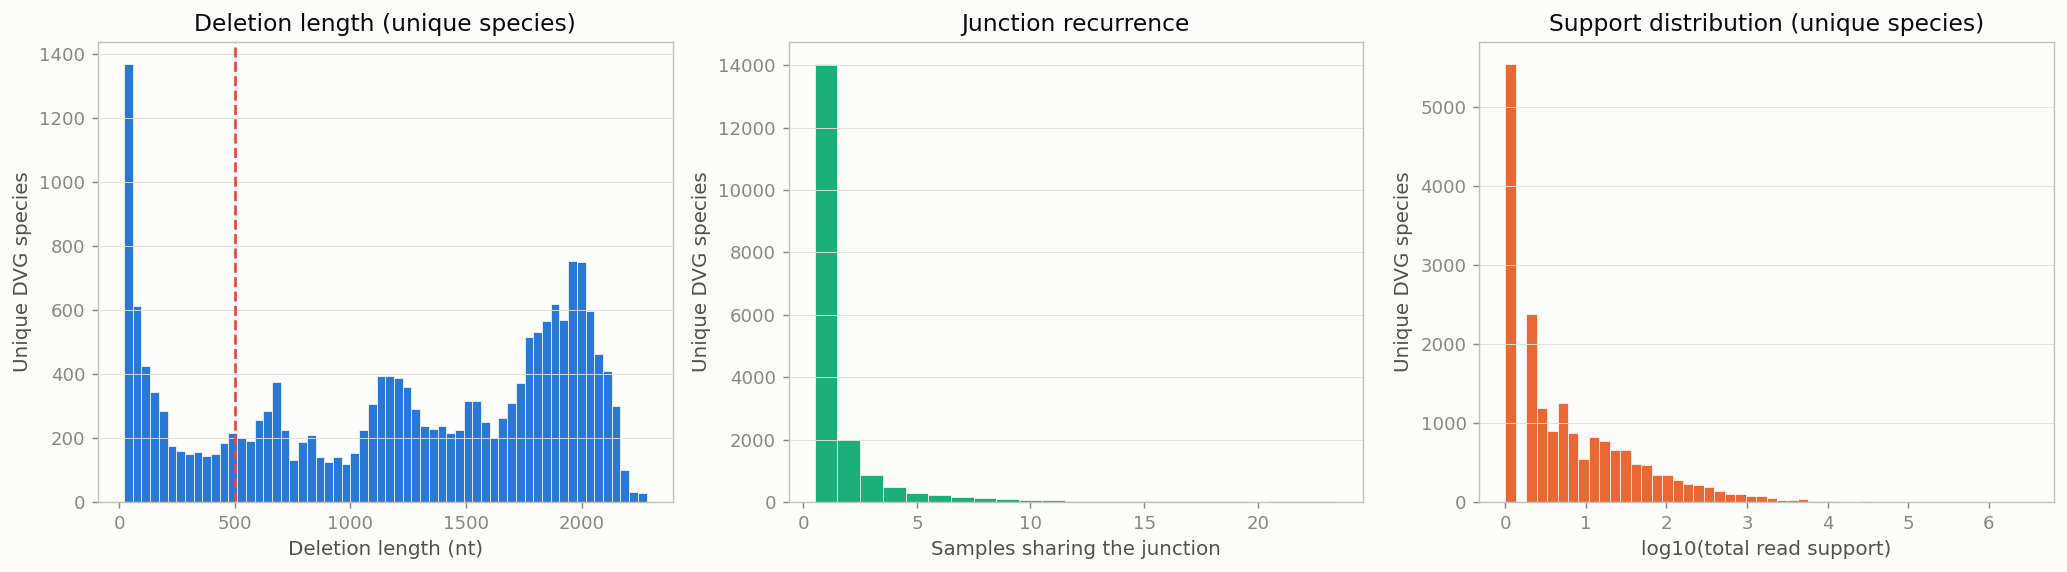

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Deletion length — unique species
ax = axes[0]
ax.hist(
    df_unique['deletion_length'], bins=60,
    color=PAL['blue'], edgecolor=SURFACE, linewidth=0.4,
)
ax.axvline(
    LONG_DVG_THRESHOLD, color=PAL['red'],
    linewidth=1.5, ls='--',
)
ax.set_xlabel('Deletion length (nt)')
ax.set_ylabel('Unique DVG species')
ax.set_title('Deletion length (unique species)')
ax.grid(axis='y', linewidth=0.5)

# Recurrence: how many samples share each junction
ax = axes[1]
ax.hist(
    df_unique['n_samples'], bins=range(1, int(df_unique['n_samples'].max()) + 2),
    color=PAL['aqua'], edgecolor=SURFACE, linewidth=0.4,
    align='left',
)
ax.set_xlabel('Samples sharing the junction')
ax.set_ylabel('Unique DVG species')
ax.set_title('Junction recurrence')
ax.grid(axis='y', linewidth=0.5)

# Total support per unique junction (log)
ax = axes[2]
ax.hist(
    np.log10(df_unique['total_support'].clip(lower=1)),
    bins=50, color=PAL['orange'],
    edgecolor=SURFACE, linewidth=0.4,
)
ax.set_xlabel('log10(total read support)')
ax.set_ylabel('Unique DVG species')
ax.set_title('Support distribution (unique species)')
ax.grid(axis='y', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch3_unique_dvg_species.png')
plt.show()

## Chapter 4 — Long DVGs (deletion_length < 500 nt)

### 4.1 Long vs short DVG classification

In [18]:
n_long = df_dvg['is_long_dvg'].sum()
n_short = (~df_dvg['is_long_dvg']).sum()
n_total = len(df_dvg)

long_support = df_dvg.loc[df_dvg['is_long_dvg'], 'NGS_read_count'].sum()
short_support = df_dvg.loc[~df_dvg['is_long_dvg'], 'NGS_read_count'].sum()
total_support = df_dvg['NGS_read_count'].sum()

classification = pd.DataFrame({
    'Category': ['Long (< 500 nt)', 'Short (≥ 500 nt)', 'Total'],
    'DVG species': [n_long, n_short, n_total],
    'Species %': [n_long/n_total, n_short/n_total, 1.0],
    'Read support': [long_support, short_support, total_support],
    'Support %': [
        long_support/total_support,
        short_support/total_support,
        1.0,
    ],
})
display(classification)

print()
display(Markdown('**Long DVG deletion length stats:**'))
long_dl = df_dvg.loc[df_dvg['is_long_dvg'], 'deletion_length']
print(long_dl.describe().to_string())

,Category,DVG species,Species %,Read support,Support %
0,Long (< 500 nt),6963,0.189,266662,0.027
1,Short (≥ 500 nt),29953,0.811,9683420,0.973
2,Total,36916,1.000,9950082,1.000


**Long DVG deletion length stats:**

count   6963.000
mean     155.173
std      138.981
min       21.000
25%       42.000
50%      100.000
75%      233.000
max      499.000


### 4.2 Long DVGs per sample and by group

In [19]:
display(Markdown('**Long DVG count per sample:**'))
print(df_sample['n_long_dvgs'].describe().to_string())

print()
display(Markdown('**Long DVG proportion per sample:**'))
print(df_sample['long_dvg_fraction'].describe().to_string())

print()
display(Markdown('**Long DVG metrics by group:**'))
long_by_group = df_sample.groupby(['virus', 'timepoint']).agg(
    n=('n_dvgs', 'size'),
    long_count_median=('n_long_dvgs', 'median'),
    long_count_iqr=('n_long_dvgs',
                     lambda x: f'{x.quantile(0.25):.0f}–{x.quantile(0.75):.0f}'),
    long_fraction_median=('long_dvg_fraction', 'median'),
    long_support_frac_median=('long_dvg_support_fraction', 'median'),
).reset_index()
display(long_by_group)

**Long DVG count per sample:**

count    45.000
mean    154.733
std     160.941
min       7.000
25%      28.000
50%      70.000
75%     255.000
max     574.000



**Long DVG proportion per sample:**

count   45.000
mean     0.167
std      0.052
min      0.072
25%      0.145
50%      0.162
75%      0.179
max      0.277



**Long DVG metrics by group:**

,virus,timepoint,n,long_count_median,long_count_iqr,long_fraction_median,long_support_frac_median
0,H5N1,3dpi,12,290.000,234–448,0.232,0.027
1,H5N1,6dpi,11,28.000,20–52,0.145,0.023
2,H7N9,3dpi,12,134.500,68–276,0.158,0.020
3,H7N9,6dpi,10,29.500,13–38,0.146,0.014


### 4.3 Segment distribution of long DVGs

In [20]:
long_seg = (
    df_dvg[df_dvg['is_long_dvg']]
    .groupby('Segment')
    .agg(
        n_long=('NGS_read_count', 'size'),
        long_support=('NGS_read_count', 'sum'),
    )
)
all_seg = (
    df_dvg.groupby('Segment')
    .agg(
        n_total=('NGS_read_count', 'size'),
        total_support=('NGS_read_count', 'sum'),
    )
)
seg_long = all_seg.join(long_seg, how='left').fillna(0)
seg_long['long_species_frac'] = seg_long['n_long'] / seg_long['n_total']
seg_long['long_support_frac'] = (
    seg_long['long_support'] / seg_long['total_support']
)
display(seg_long.reindex(SEGMENT_ORDER))

,n_total,total_support,n_long,long_support,long_species_frac,long_support_frac
Segment,,,,,,
PB2,7849,760759,692,34830,0.088,0.046
PB1,6733,1345696,948,134928,0.141,0.100
PA,7804,891780,975,28724,0.125,0.032
HA,2782,406902,542,10383,0.195,0.026
NP,1992,23148,674,4367,0.338,0.189
NA,5068,6356489,933,37668,0.184,0.006
M,2292,56158,1167,6271,0.509,0.112
NS,2396,109150,1032,9491,0.431,0.087


### 4.4 Most recurrent long DVG junctions

In [21]:
recurrent_long = (
    df_dvg[df_dvg['is_long_dvg']]
    .groupby(['Segment', 'Start', 'End', 'virus'])
    .agg(
        n_samples=('sample_name', 'nunique'),
        total_support=('NGS_read_count', 'sum'),
        mean_support=('NGS_read_count', 'mean'),
    )
    .reset_index()
    .sort_values('n_samples', ascending=False)
)
print(f'Long DVG junctions appearing in >1 sample: '
      f'{(recurrent_long["n_samples"] > 1).sum()}')
display(recurrent_long[recurrent_long['n_samples'] > 1].head(20))

Long DVG junctions appearing in >1 sample: 849


,Segment,Start,End,virus,n_samples,total_support,mean_support
2259,NS,178,539,H5N1,23,1036,45.043
3947,PB1,2220,2257,H7N9,22,22766,1034.818
3932,PB1,2196,2233,H5N1,22,15600,709.091
3616,PB1,164,209,H5N1,22,1287,58.500
4097,PB2,1984,2008,H5N1,21,2134,101.619
3948,PB1,2221,2257,H7N9,20,58991,2949.550
555,M,267,411,H5N1,19,144,7.579
4280,PB2,2166,2198,H5N1,19,5244,276.000
1456,NA,1217,1256,H7N9,19,3321,174.789
589,M,292,436,H7N9,18,178,9.889


### 4.5 Long DVG visualizations

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


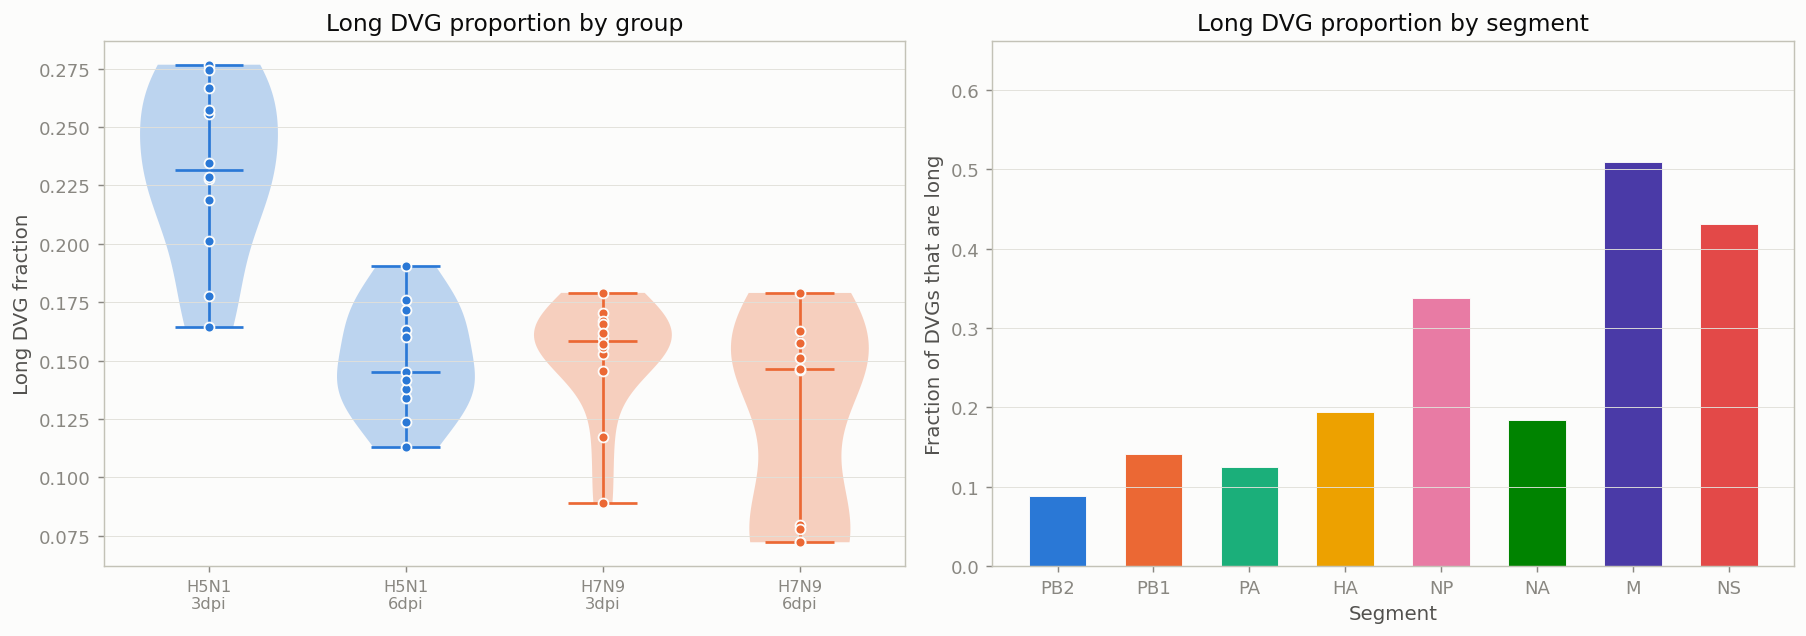

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Long DVG proportion by virus × timepoint
ax = axes[0]
grp = df_sample.groupby(['virus', 'timepoint'])
positions = {'H5N1': {}, 'H7N9': {}}
x_ticks, x_labels = [], []
for i, (v, tp) in enumerate([
    ('H5N1', '3dpi'), ('H5N1', '6dpi'),
    ('H7N9', '3dpi'), ('H7N9', '6dpi'),
]):
    sub = df_sample[
        (df_sample['virus'] == v) & (df_sample['timepoint'] == tp)
    ]
    parts = ax.violinplot(
        sub['long_dvg_fraction'].values, positions=[i],
        showmedians=True, widths=0.7,
    )
    clr = VIRUS_PAL[v]
    for pc in parts['bodies']:
        pc.set_facecolor(clr)
        pc.set_alpha(0.3)
    for key in ('cmins', 'cmaxes', 'cmedians', 'cbars'):
        if key in parts:
            parts[key].set_color(clr)
    ax.scatter(
        [i] * len(sub), sub['long_dvg_fraction'],
        color=clr, s=30, zorder=3,
        edgecolors=SURFACE, linewidths=1,
    )
    x_ticks.append(i)
    x_labels.append(f'{v}\n{tp}')
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Long DVG fraction')
ax.set_title('Long DVG proportion by group')
ax.grid(axis='y', linewidth=0.5)

# Long DVG fraction per segment
ax = axes[1]
seg_data = seg_long.reindex(SEGMENT_ORDER)
bars = ax.bar(
    SEGMENT_ORDER, seg_data['long_species_frac'],
    color=[SEG_PAL[s] for s in SEGMENT_ORDER],
    width=0.6, edgecolor=SURFACE, linewidth=0.5,
)
ax.set_ylabel('Fraction of DVGs that are long')
ax.set_title('Long DVG proportion by segment')
ax.set_xlabel('Segment')
ax.grid(axis='y', linewidth=0.5)
ax.set_ylim(0, min(1.0, seg_data['long_species_frac'].max() * 1.3))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch4_long_dvg_analysis.png')
plt.show()

## Chapter 5 — Segment Distribution

### 5.1 DVG counts and read support per segment

In [23]:
seg_summary = df_dvg.groupby('Segment').agg(
    n_dvg_species=('NGS_read_count', 'size'),
    total_support=('NGS_read_count', 'sum'),
    mean_support=('NGS_read_count', 'mean'),
    median_support=('NGS_read_count', 'median'),
    n_samples=('sample_name', 'nunique'),
)
seg_summary['segment_length'] = (
    seg_summary.index.map(SEGMENT_LENGTHS)
)
seg_summary['dvgs_per_kb'] = (
    seg_summary['n_dvg_species']
    / (seg_summary['segment_length'] / 1000)
)
seg_summary['support_per_kb'] = (
    seg_summary['total_support']
    / (seg_summary['segment_length'] / 1000)
)

display(Markdown('**DVG summary per segment (all samples pooled):**'))
display(seg_summary.reindex(SEGMENT_ORDER))

**DVG summary per segment (all samples pooled):**

,n_dvg_species,total_support,mean_support,median_support,n_samples,segment_length,dvgs_per_kb,support_per_kb
Segment,,,,,,,,
PB2,7849,760759,96.924,5.000,45,2280,3442.544,333666.228
PB1,6733,1345696,199.866,5.000,45,2274,2960.862,591774.846
PA,7804,891780,114.272,4.000,45,2151,3628.080,414588.563
HA,2782,406902,146.262,4.000,45,1704,1632.629,238792.254
NP,1992,23148,11.620,2.000,44,1497,1330.661,15462.926
NA,5068,6356489,1254.240,5.000,45,1410,3594.326,4508148.227
M,2292,56158,24.502,2.000,44,982,2334.012,57187.373
NS,2396,109150,45.555,3.000,45,838,2859.189,130250.597


### 5.2 Per-sample segment breakdown

In [24]:
sample_seg = (
    df_dvg.groupby(['sample_name', 'Segment'])
    .agg(
        n_dvgs=('NGS_read_count', 'size'),
        support=('NGS_read_count', 'sum'),
    )
    .reset_index()
)

# Dominant segment per sample (by DVG count)
dominant = (
    sample_seg.loc[
        sample_seg.groupby('sample_name')['n_dvgs'].idxmax()
    ][['sample_name', 'Segment', 'n_dvgs']]
    .rename(columns={'Segment': 'dominant_segment',
                     'n_dvgs': 'dominant_count'})
)
display(Markdown('**Dominant segment per sample (most DVG species):**'))
display(
    dominant['dominant_segment'].value_counts()
    .reindex(SEGMENT_ORDER)
    .dropna()
    .astype(int)
    .to_frame('n_samples_dominated')
)

**Dominant segment per sample (most DVG species):**

,n_samples_dominated
dominant_segment,
PB2,24
PB1,5
PA,11
NA,5


### 5.3 Segment distribution by virus type

In [25]:
display(Markdown('**DVG species count per segment, split by virus:**'))
seg_by_virus = (
    df_dvg.groupby(['virus', 'Segment'])
    .agg(
        n_species=('NGS_read_count', 'size'),
        total_support=('NGS_read_count', 'sum'),
        n_samples=('sample_name', 'nunique'),
    )
    .reset_index()
)

pivot_species = seg_by_virus.pivot(
    index='Segment', columns='virus', values='n_species'
).reindex(SEGMENT_ORDER)
pivot_support = seg_by_virus.pivot(
    index='Segment', columns='virus', values='total_support'
).reindex(SEGMENT_ORDER)

print('DVG species count:')
display(pivot_species)
print()
print('Total read support:')
display(pivot_support)

**DVG species count per segment, split by virus:**

DVG species count:


virus,H5N1,H7N9
Segment,,
PB2,3632,4217
PB1,3603,3130
PA,3524,4280
HA,2509,273
NP,1147,845
NA,2895,2173
M,1899,393
NS,1504,892



Total read support:


virus,H5N1,H7N9
Segment,,
PB2,528502,232257
PB1,667662,678034
PA,517980,373800
HA,399914,6988
NP,11101,12047
NA,1572296,4784193
M,45804,10354
NS,61229,47921


### 5.4 Segment-level long DVG proportions

In [26]:
seg_long_virus = (
    df_dvg.groupby(['virus', 'Segment'])
    .agg(
        n_total=('is_long_dvg', 'size'),
        n_long=('is_long_dvg', 'sum'),
    )
    .reset_index()
)
seg_long_virus['long_frac'] = (
    seg_long_virus['n_long'] / seg_long_virus['n_total']
)

display(Markdown('**Long DVG fraction per segment by virus:**'))
display(
    seg_long_virus.pivot(
        index='Segment', columns='virus', values='long_frac'
    ).reindex(SEGMENT_ORDER)
)

**Long DVG fraction per segment by virus:**

virus,H5N1,H7N9
Segment,,
PB2,0.087,0.089
PB1,0.141,0.141
PA,0.176,0.083
HA,0.201,0.136
NP,0.238,0.475
NA,0.219,0.138
M,0.497,0.567
NS,0.426,0.439


### 5.5 Segment distribution visualizations

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


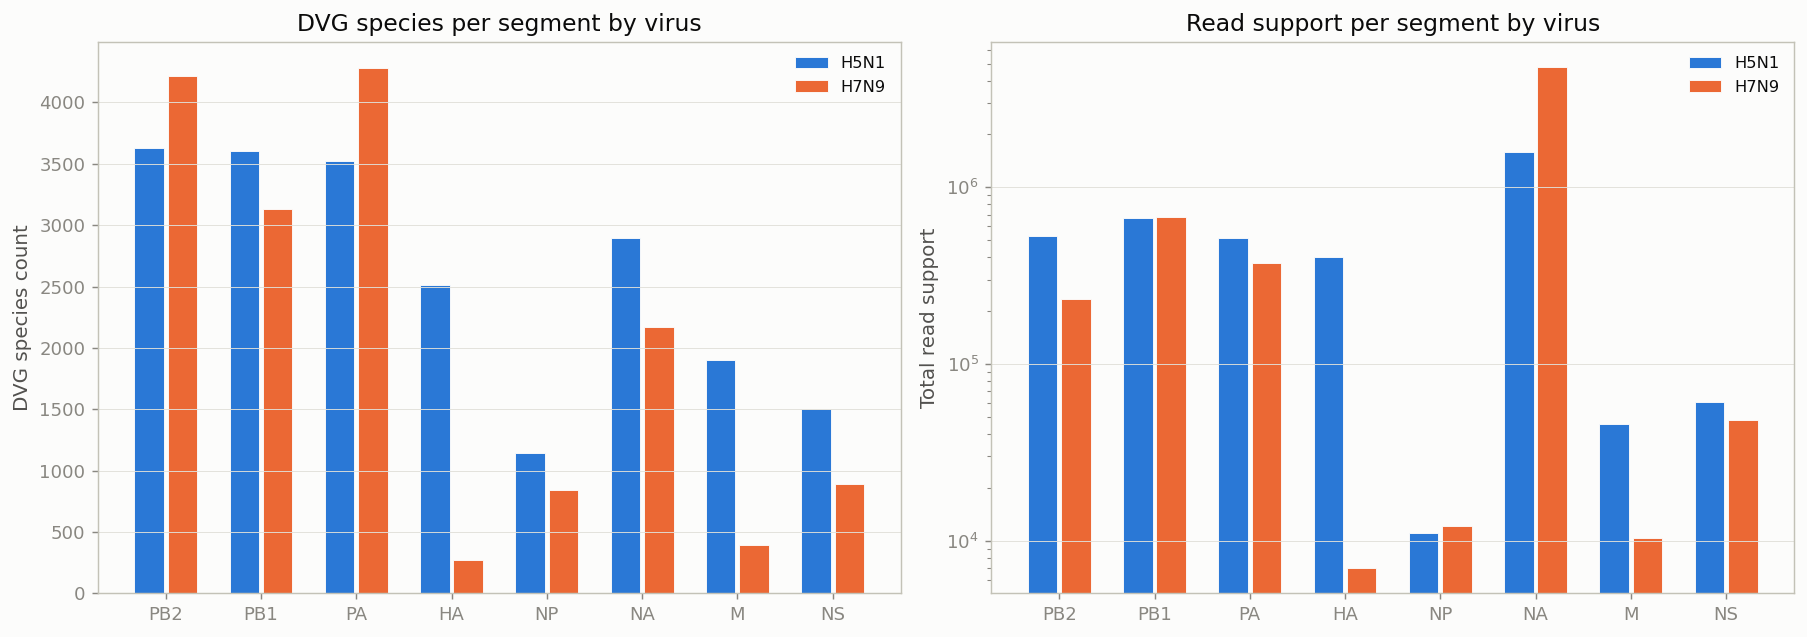

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DVG species count per segment, grouped by virus
ax = axes[0]
w = 0.35
x = np.arange(len(SEGMENT_ORDER))
for j, v in enumerate(['H5N1', 'H7N9']):
    vals = pivot_species.reindex(SEGMENT_ORDER)[v]
    ax.bar(
        x + (j - 0.5) * w, vals, width=w - 0.04,
        color=VIRUS_PAL[v], label=v,
        edgecolor=SURFACE, linewidth=0.5,
    )
ax.set_xticks(x)
ax.set_xticklabels(SEGMENT_ORDER)
ax.set_ylabel('DVG species count')
ax.set_title('DVG species per segment by virus')
ax.legend()
ax.grid(axis='y', linewidth=0.5)

# Read support per segment (log scale), grouped by virus
ax = axes[1]
for j, v in enumerate(['H5N1', 'H7N9']):
    vals = pivot_support.reindex(SEGMENT_ORDER)[v]
    ax.bar(
        x + (j - 0.5) * w, vals, width=w - 0.04,
        color=VIRUS_PAL[v], label=v,
        edgecolor=SURFACE, linewidth=0.5,
    )
ax.set_xticks(x)
ax.set_xticklabels(SEGMENT_ORDER)
ax.set_ylabel('Total read support')
ax.set_title('Read support per segment by virus')
ax.legend()
ax.grid(axis='y', linewidth=0.5)
ax.set_yscale('log')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch5_segment_distribution.png')
plt.show()

## Chapter 6 — Group Comparisons

In [28]:
def compare_groups(data, group_col, metric_col):
    """Compare a metric between groups using Mann-Whitney U
    (2 groups) or Kruskal-Wallis (3+ groups).

    Returns (summary_df, test_dict)."""
    groups = sorted(data[group_col].unique())

    summary = data.groupby(group_col)[metric_col].agg(
        ['count', 'median', 'mean', 'std']
    )
    summary['Q25'] = data.groupby(group_col)[metric_col].quantile(0.25)
    summary['Q75'] = data.groupby(group_col)[metric_col].quantile(0.75)
    summary = summary[['count', 'median', 'Q25', 'Q75', 'mean', 'std']]

    if len(groups) == 2:
        g1 = data[data[group_col] == groups[0]][metric_col].values
        g2 = data[data[group_col] == groups[1]][metric_col].values
        stat, p = stats.mannwhitneyu(
            g1, g2, alternative='two-sided'
        )
        n1, n2 = len(g1), len(g2)
        r = 1 - (2 * stat) / (n1 * n2)
        test_res = {
            'test': 'Mann-Whitney U',
            'statistic': stat, 'p_value': p,
            'effect_size': r, 'effect_type': 'rank-biserial r',
        }
    else:
        gvals = [
            data[data[group_col] == g][metric_col].values
            for g in groups
        ]
        stat, p = stats.kruskal(*gvals)
        n = len(data)
        eps2 = (stat - len(groups) + 1) / (n - len(groups))
        test_res = {
            'test': 'Kruskal-Wallis',
            'statistic': stat, 'p_value': p,
            'effect_size': eps2, 'effect_type': 'epsilon-squared',
        }

    return summary, test_res


METRICS = [
    ('n_dvgs', 'DVG species count'),
    ('total_support', 'Total read support'),
    ('n_long_dvgs', 'Long DVG count'),
    ('long_dvg_fraction', 'Long DVG proportion'),
    ('long_dvg_support_fraction', 'Long DVG support fraction'),
    ('mean_deletion_length', 'Mean deletion length'),
    ('n_segments_with_dvg', 'Segments with DVGs'),
]


def run_comparisons(df, group_col, metrics=METRICS):
    """Run all group comparisons, collect p-values for FDR."""
    results = []
    for metric_col, label in metrics:
        summary, test = compare_groups(df, group_col, metric_col)
        print(f'\n--- {label} by {group_col} ---')
        display(summary)
        print(f'  {test["test"]}: stat={test["statistic"]:.1f}, '
              f'p={test["p_value"]:.4f}, '
              f'{test["effect_type"]}={test["effect_size"]:.3f}')
        results.append({
            'metric': label,
            'group': group_col,
            **test,
        })
    return pd.DataFrame(results)

### 6.1 Virus type (H5N1 vs H7N9)

In [29]:
virus_results = run_comparisons(df_sample, 'virus')

# FDR correction
reject, pvals_adj, _, _ = multipletests(
    virus_results['p_value'], method='fdr_bh'
)
virus_results['p_adjusted'] = pvals_adj
virus_results['significant'] = reject
print('\n=== FDR-corrected results ===')
display(virus_results[[
    'metric', 'p_value', 'p_adjusted', 'effect_size', 'significant'
]])


--- DVG species count by virus ---


,count,median,Q25,Q75,mean,std
virus,,,,,,
H5N1,23,777.000,207.500,1163.500,900.565,826.902
H7N9,22,378.000,196.250,967.250,736.500,763.898


  Mann-Whitney U: stat=283.0, p=0.5030, rank-biserial r=-0.119

--- Total read support by virus ---


,count,median,Q25,Q75,mean,std
virus,,,,,,
H5N1,23,120398.000,32054.000,275756.000,165412.522,151267.753
H7N9,22,136094.500,109992.250,481806.750,279345.182,250328.747


  Mann-Whitney U: stat=190.0, p=0.1559, rank-biserial r=0.249

--- Long DVG count by virus ---


...

,count,median,Q25,Q75,mean,std
virus,,,,,,
H5N1,23,1308.419,1182.979,1387.884,1297.168,113.271
H7N9,22,1406.410,1376.493,1448.659,1415.860,59.872


  Mann-Whitney U: stat=106.0, p=0.0009, rank-biserial r=0.581

--- Segments with DVGs by virus ---


,count,median,Q25,Q75,mean,std
virus,,,,,,
H5N1,23,8.000,8.000,8.000,8.000,0.000
H7N9,22,8.000,8.000,8.000,7.909,0.294


  Mann-Whitney U: stat=276.0, p=0.1525, rank-biserial r=-0.091

=== FDR-corrected results ===


,metric,p_value,p_adjusted,effect_size,significant
0,DVG species count,0.503,0.503,-0.119,False
1,Total read support,0.156,0.218,0.249,False
2,Long DVG count,0.212,0.247,-0.219,False
3,Long DVG proportion,0.003,0.009,-0.526,True
4,Long DVG support fraction,0.091,0.212,-0.296,False
5,Mean deletion length,0.001,0.006,0.581,True
6,Segments with DVGs,0.152,0.218,-0.091,False


### 6.2 Sex (male vs female)

In [30]:
sex_results = run_comparisons(df_sample, 'sex')

reject, pvals_adj, _, _ = multipletests(
    sex_results['p_value'], method='fdr_bh'
)
sex_results['p_adjusted'] = pvals_adj
sex_results['significant'] = reject
print('\n=== FDR-corrected results ===')
display(sex_results[[
    'metric', 'p_value', 'p_adjusted', 'effect_size', 'significant'
]])


--- DVG species count by sex ---


,count,median,Q25,Q75,mean,std
sex,,,,,,
female,23,404.000,179.000,799.000,581.870,572.911
male,22,802.000,249.750,1769.500,1069.682,918.154


  Mann-Whitney U: stat=176.0, p=0.0824, rank-biserial r=0.304

--- Total read support by sex ---


,count,median,Q25,Q75,mean,std
sex,,,,,,
female,23,124367.000,25501.000,262740.000,184465.522,193126.764
male,22,172911.000,63622.250,402106.750,259426.136,226944.343


  Mann-Whitney U: stat=199.0, p=0.2245, rank-biserial r=0.213

--- Long DVG count by sex ---


...

,count,median,Q25,Q75,mean,std
sex,,,,,,
female,23,1405.191,1277.161,1466.112,1368.972,124.048
male,22,1371.382,1314.268,1402.781,1340.792,89.573


  Mann-Whitney U: stat=312.0, p=0.1841, rank-biserial r=-0.233

--- Segments with DVGs by sex ---


,count,median,Q25,Q75,mean,std
sex,,,,,,
female,23,8.000,8.000,8.000,7.913,0.288
male,22,8.000,8.000,8.000,8.000,0.000


  Mann-Whitney U: stat=231.0, p=0.1715, rank-biserial r=0.087

=== FDR-corrected results ===


,metric,p_value,p_adjusted,effect_size,significant
0,DVG species count,0.082,0.192,0.304,False
1,Total read support,0.224,0.224,0.213,False
2,Long DVG count,0.059,0.192,0.330,False
3,Long DVG proportion,0.216,0.224,0.217,False
4,Long DVG support fraction,0.052,0.192,0.340,False
5,Mean deletion length,0.184,0.224,-0.233,False
6,Segments with DVGs,0.172,0.224,0.087,False


### 6.3 Timepoint (3 dpi vs 6 dpi)

In [31]:
tp_results = run_comparisons(df_sample, 'timepoint')

reject, pvals_adj, _, _ = multipletests(
    tp_results['p_value'], method='fdr_bh'
)
tp_results['p_adjusted'] = pvals_adj
tp_results['significant'] = reject
print('\n=== FDR-corrected results ===')
display(tp_results[[
    'metric', 'p_value', 'p_adjusted', 'effect_size', 'significant'
]])


--- DVG species count by timepoint ---


,count,median,Q25,Q75,mean,std
timepoint,,,,,,
3dpi,24,1097.000,770.750,1890.000,1336.250,769.221
6dpi,21,190.000,151.000,308.000,230.762,123.128


  Mann-Whitney U: stat=487.0, p=0.0000, rank-biserial r=-0.933

--- Total read support by timepoint ---


,count,median,Q25,Q75,mean,std
timepoint,,,,,,
3dpi,24,354830.000,172143.000,467092.250,353485.083,209924.621
6dpi,21,62115.000,22079.000,110584.000,69830.476,50295.920


  Mann-Whitney U: stat=464.0, p=0.0000, rank-biserial r=-0.841

--- Long DVG count by timepoint ---


...

,count,median,Q25,Q75,mean,std
timepoint,,,,,,
3dpi,24,1328.626,1184.479,1403.404,1307.666,119.428
6dpi,21,1407.629,1368.021,1456.077,1409.514,59.886


  Mann-Whitney U: stat=128.0, p=0.0050, rank-biserial r=0.492

--- Segments with DVGs by timepoint ---


,count,median,Q25,Q75,mean,std
timepoint,,,,,,
3dpi,24,8.000,8.000,8.000,8.000,0.000
6dpi,21,8.000,8.000,8.000,7.905,0.301


  Mann-Whitney U: stat=276.0, p=0.1343, rank-biserial r=-0.095

=== FDR-corrected results ===


,metric,p_value,p_adjusted,effect_size,significant
0,DVG species count,0.000,0.000,-0.933,True
1,Total read support,0.000,0.000,-0.841,True
2,Long DVG count,0.000,0.000,-0.917,True
3,Long DVG proportion,0.001,0.001,-0.603,True
4,Long DVG support fraction,0.641,0.641,-0.083,False
5,Mean deletion length,0.005,0.007,0.492,True
6,Segments with DVGs,0.134,0.157,-0.095,False


### 6.4 Group comparison visualizations

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


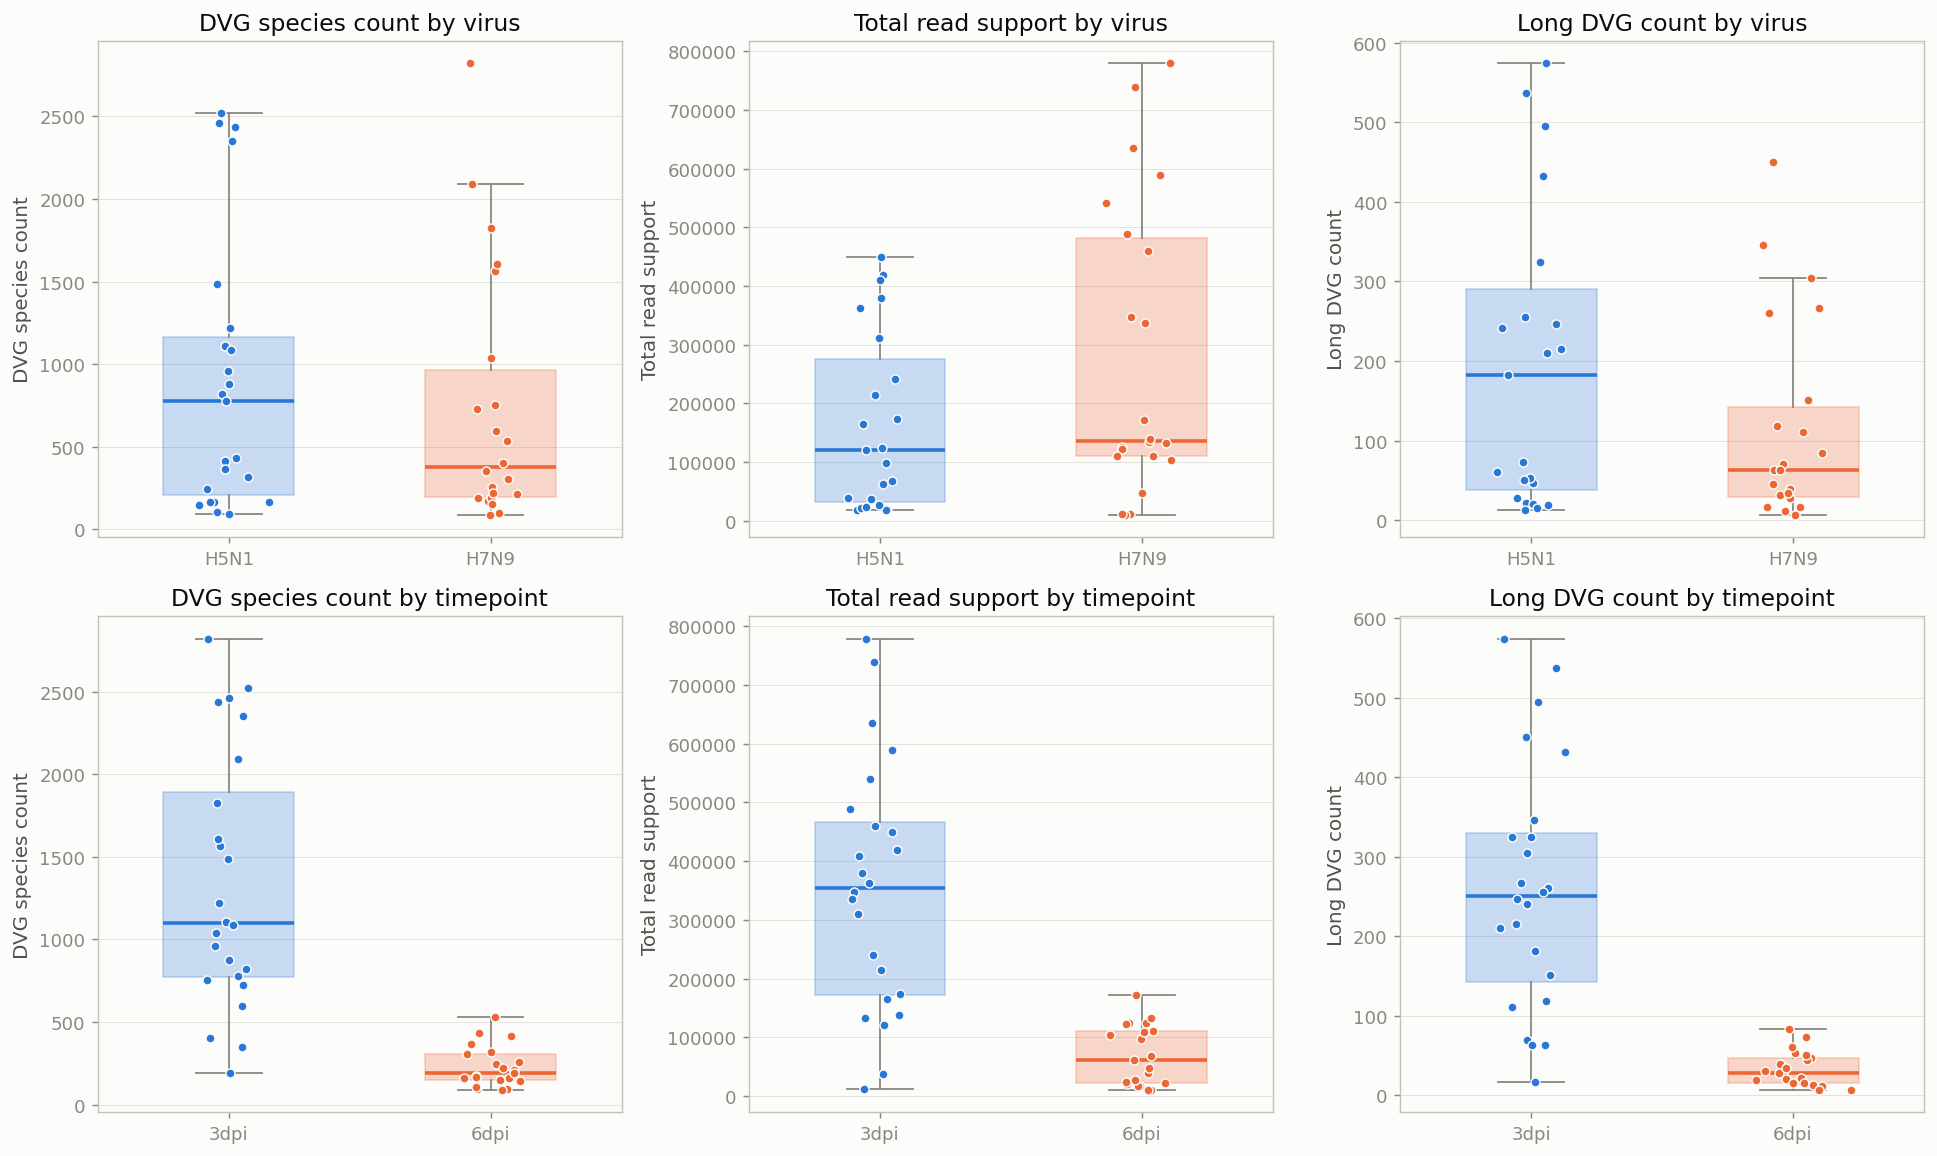

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

plot_specs = [
    ('virus', 'n_dvgs', 'DVG species count', VIRUS_PAL),
    ('virus', 'total_support', 'Total read support', VIRUS_PAL),
    ('virus', 'n_long_dvgs', 'Long DVG count', VIRUS_PAL),
    ('timepoint', 'n_dvgs', 'DVG species count', TP_PAL),
    ('timepoint', 'total_support', 'Total read support', TP_PAL),
    ('timepoint', 'n_long_dvgs', 'Long DVG count', TP_PAL),
]

for ax, (grp_col, metric, ylabel, pal) in zip(axes.flat, plot_specs):
    groups = sorted(df_sample[grp_col].unique())
    for i, g in enumerate(groups):
        sub = df_sample[df_sample[grp_col] == g][metric]
        bp = ax.boxplot(
            sub.values, positions=[i], widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=pal[g], alpha=0.25, edgecolor=pal[g]),
            medianprops=dict(color=pal[g], linewidth=2),
            whiskerprops=dict(color=INK_MUTED),
            capprops=dict(color=INK_MUTED),
            flierprops=dict(marker='', linewidth=0),
        )
        ax.scatter(
            np.random.normal(i, 0.06, len(sub)), sub,
            color=pal[g], s=25, zorder=3,
            edgecolors=SURFACE, linewidths=0.8,
        )
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by {grp_col}')
    ax.grid(axis='y', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch6_group_comparisons.png')
plt.show()

## Chapter 7 — Interaction Effects

### 7.1 Full factorial summary

In [33]:
factorial = df_sample.groupby(
    ['virus', 'sex', 'timepoint']
).agg(
    n=('n_dvgs', 'size'),
    dvg_count_median=('n_dvgs', 'median'),
    dvg_count_mean=('n_dvgs', 'mean'),
    support_median=('total_support', 'median'),
    support_mean=('total_support', 'mean'),
    long_count_median=('n_long_dvgs', 'median'),
    long_frac_median=('long_dvg_fraction', 'median'),
).reset_index()

display(Markdown(
    '**Full factorial summary '
    '(Virus × Sex × Timepoint):**'
))
display(factorial)

**Full factorial summary (Virus × Sex × Timepoint):**

,virus,sex,timepoint,n,dvg_count_median,dvg_count_mean,support_median,support_mean,long_count_median,long_frac_median
0,H5N1,female,3dpi,6,1023.000,1275.000,262740.000,279878.000,251.000,0.245
1,H5N1,female,6dpi,5,168.000,223.000,24090.000,42805.400,19.000,0.142
2,H5N1,male,3dpi,6,1785.000,1741.500,301550.000,267355.167,378.500,0.215
3,H5N1,male,6dpi,6,205.500,249.833,50421.000,51177.000,37.500,0.158
4,H7N9,female,3dpi,6,501.000,556.000,237537.500,309912.333,66.500,0.151
5,H7N9,female,6dpi,6,170.500,213.667,106554.500,81656.333,14.000,0.079
6,H7N9,male,3dpi,6,1716.000,1772.500,565070.500,556794.833,285.500,0.164
7,H7N9,male,6dpi,4,235.000,237.500,117825.500,113853.250,35.000,0.149


### 7.2 Stratified comparisons

In [34]:
display(Markdown('**Virus effect, stratified by timepoint:**'))
stratified_results = []

for tp in ['3dpi', '6dpi']:
    subset = df_sample[df_sample['timepoint'] == tp]
    print(f'\n====== {tp} ======')
    for metric_col, label in METRICS:
        _, test = compare_groups(subset, 'virus', metric_col)
        stratified_results.append({
            'stratum': tp,
            'comparison': 'virus',
            'metric': label,
            'p_value': test['p_value'],
            'effect_size': test['effect_size'],
        })
        sig = '*' if test['p_value'] < 0.05 else ''
        print(f'  {label}: p={test["p_value"]:.4f} '
              f'r={test["effect_size"]:.3f} {sig}')

print()
display(Markdown('**Timepoint effect, stratified by virus:**'))
for v in ['H5N1', 'H7N9']:
    subset = df_sample[df_sample['virus'] == v]
    print(f'\n====== {v} ======')
    for metric_col, label in METRICS:
        _, test = compare_groups(subset, 'timepoint', metric_col)
        stratified_results.append({
            'stratum': v,
            'comparison': 'timepoint',
            'metric': label,
            'p_value': test['p_value'],
            'effect_size': test['effect_size'],
        })
        sig = '*' if test['p_value'] < 0.05 else ''
        print(f'  {label}: p={test["p_value"]:.4f} '
              f'r={test["effect_size"]:.3f} {sig}')

df_stratified = pd.DataFrame(stratified_results)

**Virus effect, stratified by timepoint:**


====== 3dpi ======
  DVG species count: p=0.1749 r=-0.333 
  Total read support: p=0.0885 r=0.417 
  Long DVG count: p=0.0350 r=-0.514 *
  Long DVG proportion: p=0.0001 r=-0.931 *
  Long DVG support fraction: p=0.1572 r=-0.347 
  Mean deletion length: p=0.0000 r=1.000 *
  Segments with DVGs: p=1.0000 r=0.000 

====== 6dpi ======
  DVG species count: p=0.9159 r=-0.036 
  Total read support: p=0.0845 r=0.455 
  Long DVG count: p=0.3978 r=-0.227 
  Long DVG proportion: p=0.3418 r=-0.255 
  Long DVG support fraction: p=0.3418 r=-0.255 
  Mean deletion length: p=0.5035 r=0.182 
  Segments with DVGs: p=0.1463 r=-0.200 



**Timepoint effect, stratified by virus:**


====== H5N1 ======
  DVG species count: p=0.0001 r=-1.000 *
  Total read support: p=0.0003 r=-0.909 *
  Long DVG count: p=0.0001 r=-1.000 *
  Long DVG proportion: p=0.0002 r=-0.939 *
  Long DVG support fraction: p=0.7350 r=-0.091 
  Mean deletion length: p=0.0001 r=1.000 *
  Segments with DVGs: p=1.0000 r=0.000 

====== H7N9 ======
  DVG species count: p=0.0005 r=-0.883 *
  Total read support: p=0.0011 r=-0.833 *
  Long DVG count: p=0.0009 r=-0.850 *
  Long DVG proportion: p=0.0927 r=-0.433 
  Long DVG support fraction: p=0.3390 r=-0.250 
  Mean deletion length: p=0.8691 r=0.050 
  Segments with DVGs: p=0.1282 r=-0.200 


### 7.3 Normality check & parametric ANOVA (if appropriate)

In [35]:
display(Markdown('**Shapiro-Wilk normality test on DVG count:**'))
normal_ok = True
for name, grp in df_sample.groupby(['virus', 'timepoint']):
    if len(grp) < 3:
        continue
    stat, p = stats.shapiro(grp['n_dvgs'])
    flag = '  ← non-normal' if p < 0.05 else ''
    print(f'  {name}: W={stat:.3f}, p={p:.4f}{flag}')
    if p < 0.05:
        normal_ok = False

print()
if normal_ok:
    print('All groups pass normality → running parametric ANOVA.')
else:
    print('Some groups deviate from normality. '
          'ANOVA results should be interpreted with caution.')

print()
display(Markdown('**Two-way ANOVA (Type II) on DVG count:**'))
try:
    model = ols(
        'n_dvgs ~ C(virus) * C(sex) * C(timepoint)',
        data=df_sample,
    ).fit()
    anova_table = anova_lm(model, typ=2)
    display(anova_table)
except Exception as e:
    print(f'ANOVA failed: {e}')

print()
display(Markdown('**Two-way ANOVA (Type II) on total read support:**'))
try:
    model2 = ols(
        'total_support ~ C(virus) * C(sex) * C(timepoint)',
        data=df_sample,
    ).fit()
    anova_table2 = anova_lm(model2, typ=2)
    display(anova_table2)
except Exception as e:
    print(f'ANOVA failed: {e}')

**Shapiro-Wilk normality test on DVG count:**

  ('H5N1', '3dpi'): W=0.803, p=0.0102  ← non-normal
  ('H5N1', '6dpi'): W=0.886, p=0.1221
  ('H7N9', '3dpi'): W=0.927, p=0.3500
  ('H7N9', '6dpi'): W=0.849, p=0.0565

Some groups deviate from normality. ANOVA results should be interpreted with caution.



**Two-way ANOVA (Type II) on DVG count:**

,sum_sq,df,F,PR(>F)
C(virus),403548.316,1.000,1.842,0.183
C(sex),2410832.976,1.000,11.005,0.002
C(timepoint),13060272.754,1.000,59.618,0.000
C(virus):C(sex),452720.800,1.000,2.067,0.159
C(virus):C(timepoint),330929.839,1.000,1.511,0.227
C(sex):C(timepoint),1781716.887,1.000,8.133,0.007
C(virus):C(sex):C(timepoint),391040.690,1.000,1.785,0.190
Residual,8105414.167,37.000,NaN,NaN


**Two-way ANOVA (Type II) on total read support:**

,sum_sq,df,F,PR(>F)
C(virus),132624063078.824,1.000,6.878,0.013
C(sex),57974970775.582,1.000,3.007,0.091
C(timepoint),832134370158.845,1.000,43.157,0.000
C(virus):C(sex),63386900233.802,1.000,3.287,0.078
C(virus):C(timepoint),30398798208.784,1.000,1.577,0.217
C(sex):C(timepoint),23802437196.506,1.000,1.234,0.274
C(virus):C(sex):C(timepoint),38274444312.184,1.000,1.985,0.167
Residual,713416127438.283,37.000,NaN,NaN


### 7.4 Interaction visualizations

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


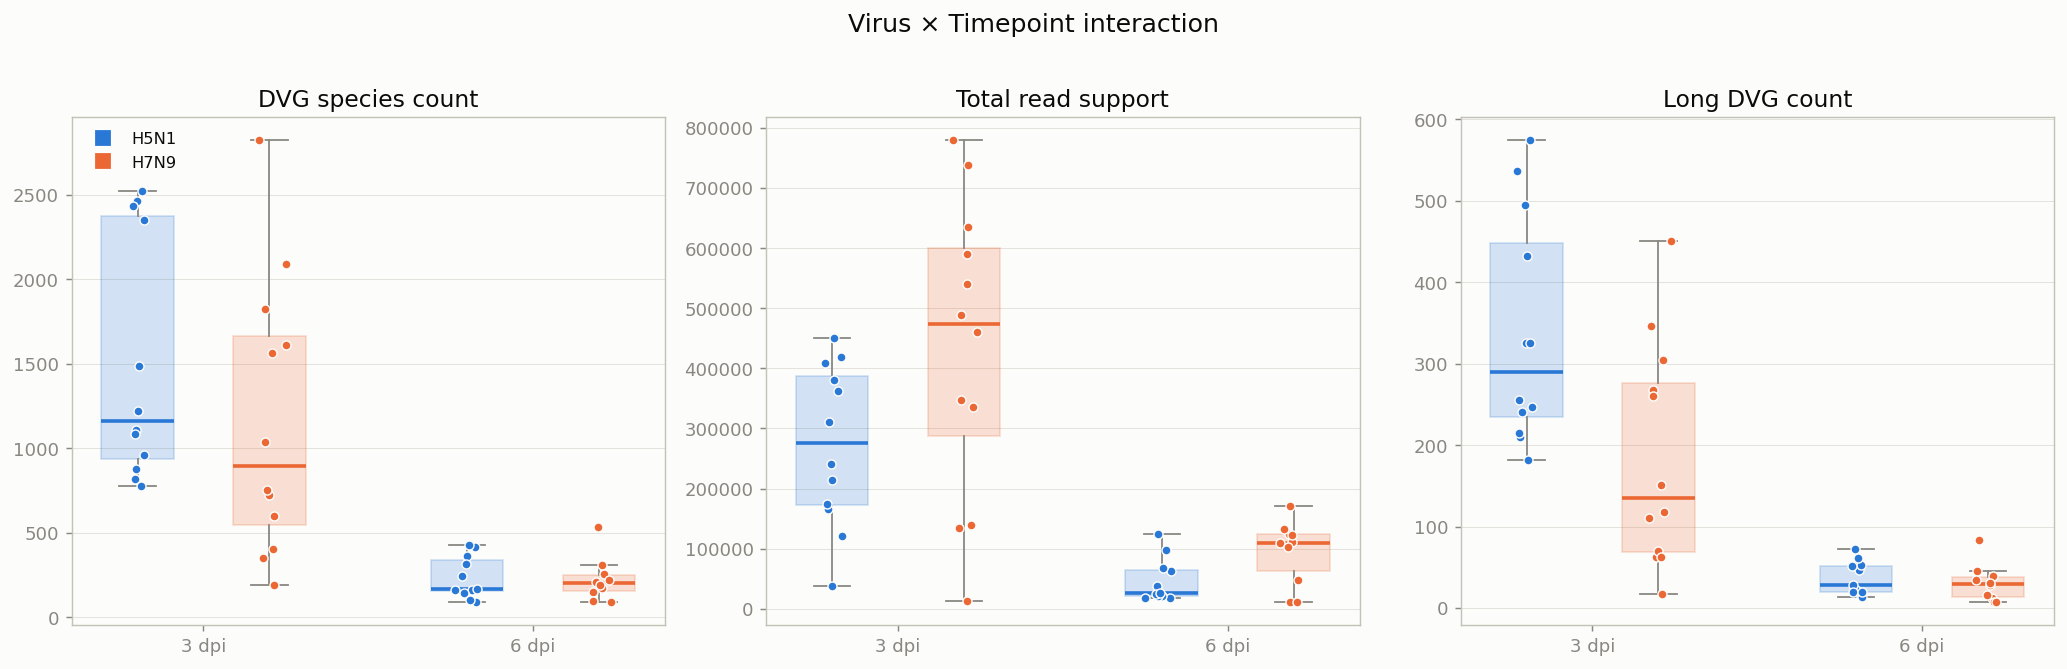

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title) in zip(axes, [
    ('n_dvgs', 'DVG species count'),
    ('total_support', 'Total read support'),
    ('n_long_dvgs', 'Long DVG count'),
]):
    for i, tp in enumerate(['3dpi', '6dpi']):
        for j, v in enumerate(['H5N1', 'H7N9']):
            sub = df_sample[
                (df_sample['virus'] == v)
                & (df_sample['timepoint'] == tp)
            ]
            x_pos = i * 2.5 + j
            bp = ax.boxplot(
                sub[metric].values, positions=[x_pos],
                widths=0.55, patch_artist=True,
                boxprops=dict(
                    facecolor=VIRUS_PAL[v], alpha=0.2,
                    edgecolor=VIRUS_PAL[v],
                ),
                medianprops=dict(color=VIRUS_PAL[v], lw=2),
                whiskerprops=dict(color=INK_MUTED),
                capprops=dict(color=INK_MUTED),
                flierprops=dict(marker='', lw=0),
            )
            jitter = np.random.normal(0, 0.05, len(sub))
            ax.scatter(
                x_pos + jitter, sub[metric],
                color=VIRUS_PAL[v], s=25, zorder=3,
                edgecolors=SURFACE, linewidths=0.8,
            )
    ax.set_xticks([0.5, 3.0])
    ax.set_xticklabels(['3 dpi', '6 dpi'])
    ax.set_title(title)
    ax.grid(axis='y', linewidth=0.5)

# Shared legend
for v, c in VIRUS_PAL.items():
    axes[0].plot([], [], 's', color=c, label=v, markersize=8)
axes[0].legend(loc='upper left')

fig.suptitle(
    'Virus × Timepoint interaction', fontsize=14,
    color=INK_1, y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch7_interaction_effects.png')
plt.show()

## Chapter 8 — Junction Characterization

### 8.1 Breakpoint position analysis

In [37]:
display(Markdown(
    '**Breakpoint positions (fraction of segment length):**'
))
bp_stats = df_dvg.groupby('Segment').agg(
    start_mean=('start_frac', 'mean'),
    start_median=('start_frac', 'median'),
    start_std=('start_frac', 'std'),
    end_mean=('end_frac', 'mean'),
    end_median=('end_frac', 'median'),
    end_std=('end_frac', 'std'),
    n=('start_frac', 'size'),
).reindex(SEGMENT_ORDER)
display(bp_stats)

print()
display(Markdown(
    '**Breakpoint positions split by virus:**'
))
bp_virus = df_dvg.groupby(['virus', 'Segment']).agg(
    start_median=('start_frac', 'median'),
    end_median=('end_frac', 'median'),
    n=('start_frac', 'size'),
).reset_index()
for v in ['H5N1', 'H7N9']:
    print(f'\n{v}:')
    display(
        bp_virus[bp_virus['virus'] == v]
        .set_index('Segment')
        .reindex(SEGMENT_ORDER)
        .drop(columns='virus')
    )

**Breakpoint positions (fraction of segment length):**

,start_mean,start_median,start_std,end_mean,end_median,end_std,n
Segment,,,,,,,
PB2,0.139,0.080,0.214,0.900,0.920,0.121,7849
PB1,0.144,0.065,0.231,0.861,0.924,0.216,6733
PA,0.146,0.085,0.215,0.866,0.915,0.190,7804
HA,0.199,0.063,0.291,0.867,0.906,0.156,2782
NP,0.311,0.176,0.304,0.844,0.898,0.207,1992
NA,0.210,0.085,0.267,0.858,0.884,0.152,5068
M,0.302,0.257,0.236,0.784,0.865,0.203,2292
NS,0.252,0.186,0.223,0.810,0.863,0.171,2396


**Breakpoint positions split by virus:**


H5N1:


,start_median,end_median,n
Segment,,,
PB2,0.072,0.916,3632
PB1,0.061,0.916,3603
PA,0.066,0.920,3524
HA,0.062,0.912,2509
NP,0.092,0.888,1147
NA,0.106,0.910,2895
M,0.254,0.866,1899
NS,0.159,0.866,1504



H7N9:


,start_median,end_median,n
Segment,,,
PB2,0.084,0.922,4217
PB1,0.069,0.927,3130
PA,0.097,0.913,4280
HA,0.078,0.869,273
NP,0.331,0.931,845
NA,0.081,0.879,2173
M,0.297,0.843,393
NS,0.229,0.858,892


### 8.2 Strand bias analysis (from .par files)

In [38]:
display(Markdown('**Strand ratio (Forward / Total) per segment:**'))
strand_stats = (
    df_par.groupby('Segment')['strand_ratio']
    .agg(['count', 'mean', 'median', 'std'])
    .reindex(SEGMENT_ORDER)
)

# Wilcoxon signed-rank test: strand_ratio vs 0.5
strand_pvals = []
for seg in SEGMENT_ORDER:
    seg_data = df_par[
        df_par['Segment'] == seg
    ]['strand_ratio'].dropna()
    if len(seg_data) >= 10:
        try:
            stat, p = stats.wilcoxon(seg_data - 0.5)
            strand_stats.loc[seg, 'wilcoxon_p'] = p
            strand_pvals.append((seg, p))
        except Exception:
            strand_stats.loc[seg, 'wilcoxon_p'] = np.nan
    else:
        strand_stats.loc[seg, 'wilcoxon_p'] = np.nan

display(strand_stats)

# FDR correction on strand bias p-values
if strand_pvals:
    segs, pvals = zip(*strand_pvals)
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    print('\nFDR-corrected strand bias p-values:')
    for s, pa in zip(segs, pvals_adj):
        sig = '*' if pa < 0.05 else ''
        print(f'  {s}: p_adj={pa:.4f} {sig}')

**Strand ratio (Forward / Total) per segment:**

,count,mean,median,std,wilcoxon_p
Segment,,,,,
PB2,7849.000,0.683,0.830,0.363,0.000
PB1,6733.000,0.692,0.890,0.377,0.000
PA,7804.000,0.619,0.670,0.386,0.000
HA,2782.000,0.680,0.983,0.404,0.000
NP,1992.000,0.593,0.900,0.445,0.000
NA,NaN,NaN,NaN,NaN,NaN
M,2292.000,0.530,0.500,0.452,0.000
NS,2396.000,0.454,0.471,0.425,0.000



FDR-corrected strand bias p-values:
  PB2: p_adj=0.0000 *
  PB1: p_adj=0.0000 *
  PA: p_adj=0.0000 *
  HA: p_adj=0.0000 *
  NP: p_adj=0.0000 *
  M: p_adj=0.0001 *
  NS: p_adj=0.0000 *


### 8.3 Fuzz factor analysis

In [39]:
display(Markdown('**Fuzz factor distribution:**'))
fuzz = df_par['Fuzz_factor']
print(f'  Mean:   {fuzz.mean():.2f}')
print(f'  Median: {fuzz.median():.0f}')
print(f'  Max:    {fuzz.max():.0f}')
print(f'  Fuzz = 0: {(fuzz == 0).sum()} '
      f'({(fuzz == 0).mean():.1%})')
print(f'  Fuzz > 0: {(fuzz > 0).sum()} '
      f'({(fuzz > 0).mean():.1%})')

print()
display(Markdown('**Fuzz factor by segment:**'))
display(
    df_par.groupby('Segment')['Fuzz_factor']
    .agg(['mean', 'median', 'max'])
    .reindex(SEGMENT_ORDER)
)

**Fuzz factor distribution:**

  Mean:   0.00
  Median: 0
  Max:    0
  Fuzz = 0: 36916 (100.0%)
  Fuzz > 0: 0 (0.0%)



**Fuzz factor by segment:**

,mean,median,max
Segment,,,
PB2,0.000,0.000,0.000
PB1,0.000,0.000,0.000
PA,0.000,0.000,0.000
HA,0.000,0.000,0.000
NP,0.000,0.000,0.000
NA,NaN,NaN,NaN
M,0.000,0.000,0.000
NS,0.000,0.000,0.000


### 8.4 Recurrent junctions across samples

In [40]:
display(Markdown('**Recurrent DVG junctions (all DVGs):**'))

# Within-virus recurrence
junction_within = (
    df_dvg.groupby(['virus', 'Segment', 'Start', 'End'])
    .agg(
        n_samples=('sample_name', 'nunique'),
        total_support=('NGS_read_count', 'sum'),
        samples=('sample_name', lambda x: ', '.join(
            sorted(x.unique())
        )),
    )
    .reset_index()
    .sort_values('n_samples', ascending=False)
)

recurrent_within = junction_within[
    junction_within['n_samples'] > 1
]
print(f'Junctions shared by >1 sample (within virus): '
      f'{len(recurrent_within)}')
print()

# Top 20 most shared
display(
    recurrent_within
    .head(20)
    [['virus', 'Segment', 'Start', 'End',
      'n_samples', 'total_support']]
)

print()
# Sharing distribution
display(Markdown('**How many samples share each junction:**'))
display(
    recurrent_within['n_samples']
    .value_counts()
    .sort_index()
    .to_frame('n_junctions')
)

**Recurrent DVG junctions (all DVGs):**

Junctions shared by >1 sample (within virus): 4850



,virus,Segment,Start,End,n_samples,total_support
10934,H5N1,PB2,100,1994,23,8257
11514,H5N1,PB2,214,2064,23,1338
7396,H5N1,PA,117,2080,23,5766
6277,H5N1,NS,178,539,23,1036
11167,H5N1,PB2,149,2202,23,47814
11510,H5N1,PB2,213,2063,23,130008
11684,H5N1,PB2,303,2112,23,126892
11571,H5N1,PB2,243,1958,23,4328
11238,H5N1,PB2,165,2113,23,9889
11336,H5N1,PB2,181,2075,23,11747


**How many samples share each junction:**

,n_junctions
n_samples,
2,1982
3,868
4,501
5,297
6,237
7,170
8,138
9,116
10,81


### 8.5 Cross-virus breakpoint comparison

In [41]:
display(Markdown(
    '**Cross-virus comparison '
    '(normalized breakpoint positions):**'
))

# Bin breakpoints to 5% resolution for cross-virus matching
df_dvg['start_bin'] = (df_dvg['start_frac'] * 20).round() / 20
df_dvg['end_bin'] = (df_dvg['end_frac'] * 20).round() / 20

cross_virus = (
    df_dvg.groupby(
        ['Segment', 'start_bin', 'end_bin', 'virus']
    )
    .agg(
        n_junctions=('NGS_read_count', 'size'),
        total_support=('NGS_read_count', 'sum'),
    )
    .reset_index()
)

cross_pivot = cross_virus.pivot_table(
    index=['Segment', 'start_bin', 'end_bin'],
    columns='virus',
    values='n_junctions',
    fill_value=0,
)

shared_bins = cross_pivot[
    (cross_pivot.get('H5N1', 0) > 0)
    & (cross_pivot.get('H7N9', 0) > 0)
].reset_index()

print(f'Breakpoint bins shared between both viruses: '
      f'{len(shared_bins)}')
if not shared_bins.empty:
    display(shared_bins.head(20))

**Cross-virus comparison (normalized breakpoint positions):**

Breakpoint bins shared between both viruses: 604


virus,Segment,start_bin,end_bin,H5N1,H7N9
0,HA,0.000,0.050,3.000,1.000
1,HA,0.000,0.750,6.000,1.000
2,HA,0.000,0.900,99.000,7.000
3,HA,0.000,0.950,123.000,3.000
4,HA,0.050,0.100,45.000,2.000
5,HA,0.050,0.150,1.000,1.000
6,HA,0.050,0.600,1.000,1.000
7,HA,0.050,0.700,8.000,1.000
8,HA,0.050,0.800,50.000,4.000
9,HA,0.050,0.850,177.000,42.000


### 8.6 Junction characterization visualizations

/var/folders/pq/2ktr7dcj7dv1qxs1ps0l6mlwtw_bb0/T/ipykernel_10232/1926983850.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


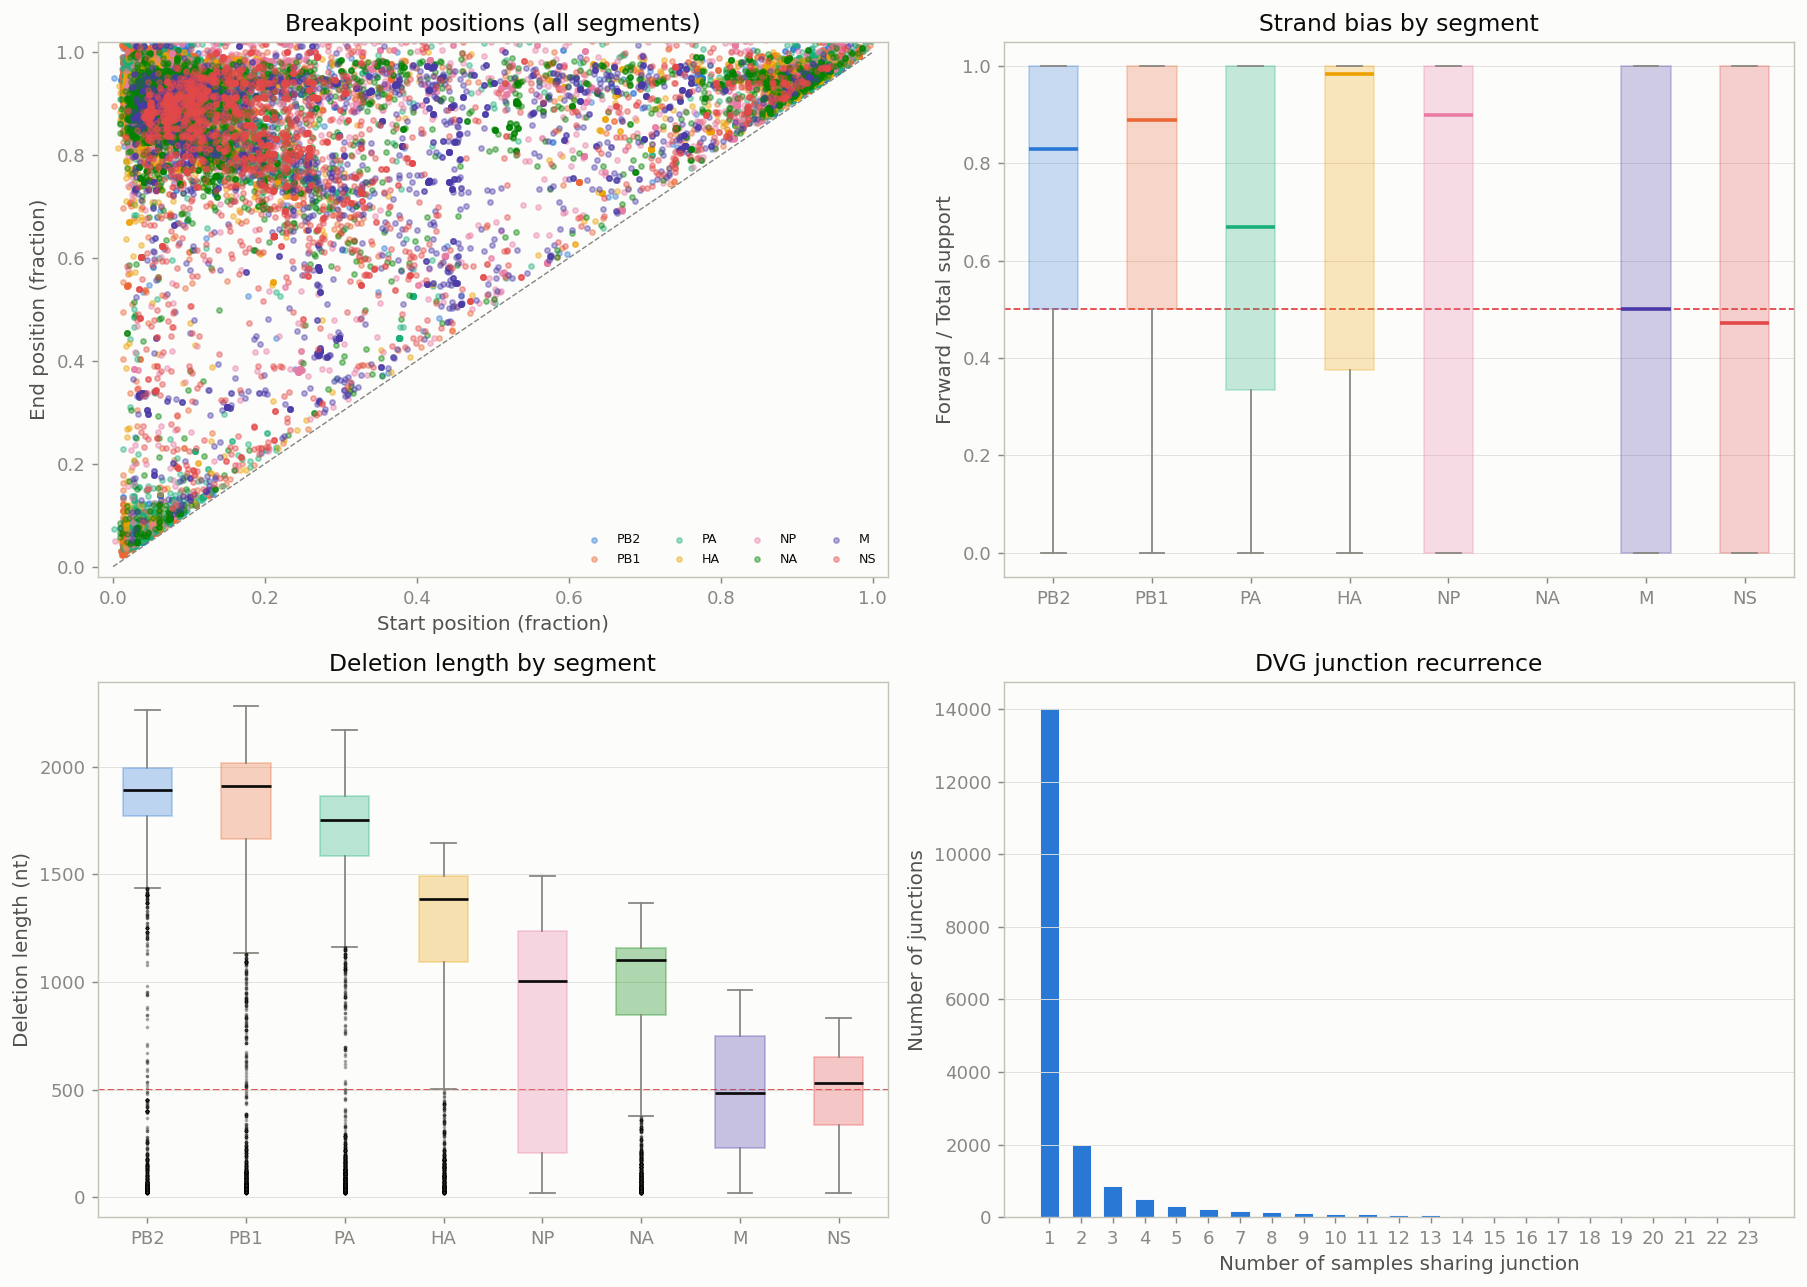

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Breakpoint positions: Start vs End by segment
ax = axes[0, 0]
for seg in SEGMENT_ORDER:
    sub = df_dvg[df_dvg['Segment'] == seg]
    ax.scatter(
        sub['start_frac'], sub['end_frac'],
        color=SEG_PAL[seg], s=8, alpha=0.4, label=seg,
    )
ax.plot([0, 1], [0, 1], color=INK_MUTED, lw=0.8, ls='--', zorder=0)
ax.set_xlabel('Start position (fraction)')
ax.set_ylabel('End position (fraction)')
ax.set_title('Breakpoint positions (all segments)')
ax.legend(fontsize=7, ncol=4, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Strand ratio by segment
ax = axes[0, 1]
medians = []
for i, seg in enumerate(SEGMENT_ORDER):
    seg_data = df_par[
        df_par['Segment'] == seg
    ]['strand_ratio'].dropna()
    bp = ax.boxplot(
        seg_data.values, positions=[i], widths=0.5,
        patch_artist=True,
        boxprops=dict(
            facecolor=SEG_PAL[seg], alpha=0.25,
            edgecolor=SEG_PAL[seg],
        ),
        medianprops=dict(color=SEG_PAL[seg], lw=2),
        whiskerprops=dict(color=INK_MUTED),
        capprops=dict(color=INK_MUTED),
        flierprops=dict(
            marker='.', markerfacecolor=SEG_PAL[seg],
            markersize=3, alpha=0.5,
        ),
    )
ax.axhline(0.5, color=PAL['red'], lw=1, ls='--', zorder=0)
ax.set_xticks(range(len(SEGMENT_ORDER)))
ax.set_xticklabels(SEGMENT_ORDER)
ax.set_ylabel('Forward / Total support')
ax.set_title('Strand bias by segment')
ax.grid(axis='y', linewidth=0.5)

# Deletion length by segment
ax = axes[1, 0]
seg_dl = []
for seg in SEGMENT_ORDER:
    seg_dl.append(
        df_dvg[df_dvg['Segment'] == seg]['deletion_length'].values
    )
bp = ax.boxplot(
    seg_dl, labels=SEGMENT_ORDER, patch_artist=True,
    medianprops=dict(color=INK_1, lw=1.5),
    whiskerprops=dict(color=INK_MUTED),
    capprops=dict(color=INK_MUTED),
    flierprops=dict(
        marker='.', markerfacecolor=INK_MUTED,
        markersize=2, alpha=0.3,
    ),
)
for patch, seg in zip(bp['boxes'], SEGMENT_ORDER):
    patch.set_facecolor(SEG_PAL[seg])
    patch.set_alpha(0.3)
    patch.set_edgecolor(SEG_PAL[seg])
ax.axhline(
    LONG_DVG_THRESHOLD, color=PAL['red'],
    lw=1, ls='--', zorder=0,
)
ax.set_ylabel('Deletion length (nt)')
ax.set_title('Deletion length by segment')
ax.grid(axis='y', linewidth=0.5)

# Recurrent junctions: sharing distribution
ax = axes[1, 1]
sharing = (
    junction_within['n_samples']
    .value_counts()
    .sort_index()
)
ax.bar(
    sharing.index.astype(str), sharing.values,
    color=PAL['blue'], width=0.6,
    edgecolor=SURFACE, linewidth=0.5,
)
ax.set_xlabel('Number of samples sharing junction')
ax.set_ylabel('Number of junctions')
ax.set_title('DVG junction recurrence')
ax.grid(axis='y', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ch8_junction_characterization.png')
plt.show()

## Chapter 9 — Summary Tables

### 9.1 Master summary table (all groups)

In [43]:
master = df_sample.groupby(
    ['virus', 'sex', 'timepoint']
).agg(
    n=('n_dvgs', 'size'),
    dvg_count=('n_dvgs', 'median'),
    dvg_count_iqr=('n_dvgs',
        lambda x: f'{x.quantile(0.25):.0f}–{x.quantile(0.75):.0f}'),
    total_support=('total_support', 'median'),
    support_iqr=('total_support',
        lambda x: f'{x.quantile(0.25):.0f}–{x.quantile(0.75):.0f}'),
    long_dvg_count=('n_long_dvgs', 'median'),
    long_dvg_frac=('long_dvg_fraction', 'median'),
    del_length_median=('median_deletion_length', 'median'),
    segments_w_dvg=('n_segments_with_dvg', 'median'),
).reset_index()

display(Markdown(
    '**Master summary — median (IQR) per group:**'
))
display(master)

**Master summary — median (IQR) per group:**

,virus,sex,timepoint,n,dvg_count,dvg_count_iqr,total_support,support_iqr,long_dvg_count,long_dvg_frac,del_length_median,segments_w_dvg
0,H5N1,female,3dpi,6,1023.000,856–1386,262740.000,177788–391384,251.000,0.245,1316.000,8.000
1,H5N1,female,6dpi,5,168.000,105–319,24090.000,20871–26912,19.000,0.142,1704.000,8.000
2,H5N1,male,3dpi,6,1785.000,1136–2413,301550.000,190983–375557,378.500,0.215,1289.000,8.000
3,H5N1,male,6dpi,6,205.500,163–336,50421.000,26241–66637,37.500,0.158,1687.500,8.000
4,H7N9,female,3dpi,6,501.000,365–714,237537.500,134822–428910,66.500,0.151,1725.500,8.000
5,H7N9,female,6dpi,6,170.500,110–213,106554.500,34292–119096,14.000,0.079,1742.000,8.000
6,H7N9,male,3dpi,6,1716.000,1577–2024,565070.500,502076–623942,285.500,0.164,1717.750,8.000
7,H7N9,male,6dpi,4,235.000,202–270,117825.500,95016–136663,35.000,0.149,1663.250,8.000


### 9.2 Top DVG junctions overall

In [44]:
# Top 20 junctions by total read support across all samples
top_junctions = (
    df_dvg.groupby(['virus', 'Segment', 'Start', 'End'])
    .agg(
        n_samples=('sample_name', 'nunique'),
        total_support=('NGS_read_count', 'sum'),
        mean_support=('NGS_read_count', 'mean'),
        deletion_length=('deletion_length', 'first'),
        is_long=('is_long_dvg', 'first'),
    )
    .reset_index()
    .sort_values('total_support', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(Markdown(
    '**Top 20 DVG junctions by total read support:**'
))
display(top_junctions)

**Top 20 DVG junctions by total read support:**

,virus,Segment,Start,End,n_samples,total_support,mean_support,deletion_length,is_long
0,H7N9,NA,92,1246,22,3066081,139367.318,1154,False
1,H5N1,NA,52,1326,23,1396359,60711.261,1274,False
2,H5N1,PB1,178,2033,23,434666,18898.522,1855,False
3,H7N9,NA,86,1240,22,404262,18375.545,1154,False
4,H7N9,NA,110,1241,22,318255,14466.136,1131,False
5,H5N1,HA,41,1438,23,316385,13755.870,1397,False
6,H5N1,PA,208,1901,23,309729,13466.478,1693,False
7,H7N9,NA,111,1259,22,236888,10767.636,1148,False
8,H7N9,NA,68,1166,22,155310,7059.545,1098,False
9,H7N9,PB1,60,2114,20,154045,7702.250,2054,False


### 9.3 Per-segment summary across all analyses

In [45]:
seg_final = df_dvg.groupby('Segment').agg(
    n_species=('NGS_read_count', 'size'),
    total_support=('NGS_read_count', 'sum'),
    n_samples=('sample_name', 'nunique'),
    pct_long=('is_long_dvg', 'mean'),
    median_del_len=('deletion_length', 'median'),
    start_median=('start_frac', 'median'),
    end_median=('end_frac', 'median'),
).reindex(SEGMENT_ORDER)

seg_final['segment_length'] = [
    SEGMENT_LENGTHS[s] for s in seg_final.index
]
seg_final['species_per_kb'] = (
    seg_final['n_species'] / (seg_final['segment_length'] / 1000)
)

display(Markdown('**Per-segment summary:**'))
display(seg_final)

**Per-segment summary:**

,n_species,total_support,n_samples,pct_long,median_del_len,start_median,end_median,segment_length,species_per_kb
Segment,,,,,,,,,
PB2,7849,760759,45,0.088,1894.000,0.080,0.920,2280,3442.544
PB1,6733,1345696,45,0.141,1913.000,0.065,0.924,2274,2960.862
PA,7804,891780,45,0.125,1755.000,0.085,0.915,2151,3628.080
HA,2782,406902,45,0.195,1385.000,0.063,0.906,1704,1632.629
NP,1992,23148,44,0.338,1003.500,0.176,0.898,1497,1330.661
NA,5068,6356489,45,0.184,1104.000,0.085,0.884,1410,3594.326
M,2292,56158,44,0.509,487.000,0.257,0.865,982,2334.012
NS,2396,109150,45,0.431,531.500,0.186,0.863,838,2859.189


### 9.4 Consolidated statistical results

In [46]:
all_results = pd.concat([
    virus_results.assign(comparison='virus'),
    sex_results.assign(comparison='sex'),
    tp_results.assign(comparison='timepoint'),
], ignore_index=True)

# Global FDR correction
reject, pvals_adj, _, _ = multipletests(
    all_results['p_value'], method='fdr_bh'
)
all_results['p_global_adj'] = pvals_adj
all_results['globally_significant'] = reject

display(Markdown(
    '**All group comparisons '
    '(global FDR correction):**'
))
display(
    all_results[[
        'comparison', 'metric', 'p_value',
        'p_adjusted', 'p_global_adj',
        'effect_size', 'globally_significant',
    ]]
    .sort_values('p_global_adj')
    .reset_index(drop=True)
)

**All group comparisons (global FDR correction):**

,comparison,metric,p_value,p_adjusted,p_global_adj,effect_size,globally_significant
0,timepoint,Long DVG count,0.000,0.000,0.000,-0.917,True
1,timepoint,DVG species count,0.000,0.000,0.000,-0.933,True
2,timepoint,Total read support,0.000,0.000,0.000,-0.841,True
3,timepoint,Long DVG proportion,0.001,0.001,0.003,-0.603,True
4,virus,Mean deletion length,0.001,0.006,0.004,0.581,True
5,virus,Long DVG proportion,0.003,0.009,0.009,-0.526,True
6,timepoint,Mean deletion length,0.005,0.007,0.015,0.492,True
7,sex,Long DVG support fraction,0.052,0.192,0.137,0.340,False
8,sex,Long DVG count,0.059,0.192,0.139,0.330,False
9,sex,DVG species count,0.082,0.192,0.173,0.304,False
